In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pvlib
from susse.estimators.validation.metrics import StatisticalMetrics

In [3]:
# Coordinates for Soroti, Uganda
latitude = 1.7157
longitude = 33.6117
tz = 'Africa/Kampala'

start = '2021-03-01'
end = '2021-03-31'

In [4]:
soroti = pvlib.location.Location(latitude, longitude, tz=tz)

In [5]:
def percentage_difference(measurement : pd.Series, prediction : pd.Series) -> pd.Series:
    return (prediction - measurement) / measurement * 100

In [6]:
def plot_ground_vs_estimate(ground : pd.Series, estimate : pd.Series):
    fig, ax = plt.subplots(2, 2, figsize=(13, 7))

    ground.plot(ax=ax[0, 0], color='blue')
    ax[0, 0].set_title('Ground Values')
    ax[0, 0].set_ylabel('GHI (kWh/m2/day)')

    estimate.plot(ax=ax[0, 1], color='orange')
    ax[0, 1].set_title('Estimate Values')
    ax[0, 1].set_ylabel('GHI (kWh/m2/day)')

    ground.plot(ax=ax[1, 0], color='blue')
    estimate.plot(ax=ax[1, 0], color='orange')
    ax[1, 0].set_title('Ground vs Estimate Values')
    ax[1, 0].set_ylabel('GHI (kWh/m2/day)')
    ax[1, 0].legend()

    diff = percentage_difference(ground, estimate)
    diff.plot(ax=ax[1, 1], color='green')
    ax[1, 1].set_title('Percentage Difference')
    ax[1, 1].set_ylabel('Percentage difference (%)')
    ax[1, 1].axhline(0, color='lightgray', lw=0.5)

    for ax in ax.flat:
        ax.set_xticks(ground.index[::2])
        ax.set_xticklabels(ground.index[::2].strftime('%d'))

    plt.tight_layout()
    plt.show()

# Ground data

In [7]:
Soroti_ground = pd.read_csv('Data/irradiation_measurements/ministry_energy_ug/cleaned/Soroti/Soroti_2021.csv')
Soroti_ground['Day'] = pd.to_datetime(Soroti_ground['Day'])
Soroti_ground = Soroti_ground.set_index('Day')

# getting data for March 2021
Soroti_ground = Soroti_ground.loc[start:end]
Soroti_ground.head()

,Temperature (C),Temperature (SAT) (C),Rain (mm),GHI_1 (kWh/m2/day),GHI_2 (kWh/m2/day),GHI_SAT (kWh/m2/day),GHI (1) vs (2) (%),GHI (1) vs (SAT) (%),DHI (1) (kWh/m2/day),DHI (SAT) (kWh/m2/day),DHI (1) vs (SAT) (%)
Day,,,,,,,,,,,
2021-03-01,28.11,27.05,0.0,6.90,6.92,7.17,-0.20,-3.84,1.56,1.76,-12.53
2021-03-02,29.07,26.95,0.0,7.41,7.43,7.41,-0.36,0.02,1.62,1.70,-5.03
2021-03-03,27.73,26.80,0.0,6.15,6.17,6.02,-0.37,2.16,2.86,3.14,-9.86
2021-03-04,25.09,26.43,0.8,4.78,4.81,4.38,-0.54,8.48,2.31,2.30,0.56
2021-03-05,26.67,26.44,1.4,6.44,6.46,7.12,-0.30,-10.53,2.02,2.07,-2.42


In [8]:
ghi_ground = Soroti_ground['GHI_1 (kWh/m2/day)']
ghi_solargis = Soroti_ground['GHI_SAT (kWh/m2/day)']
diff_solargis = Soroti_ground['GHI (1) vs (SAT) (%)']
temperature = Soroti_ground['Temperature (C)']

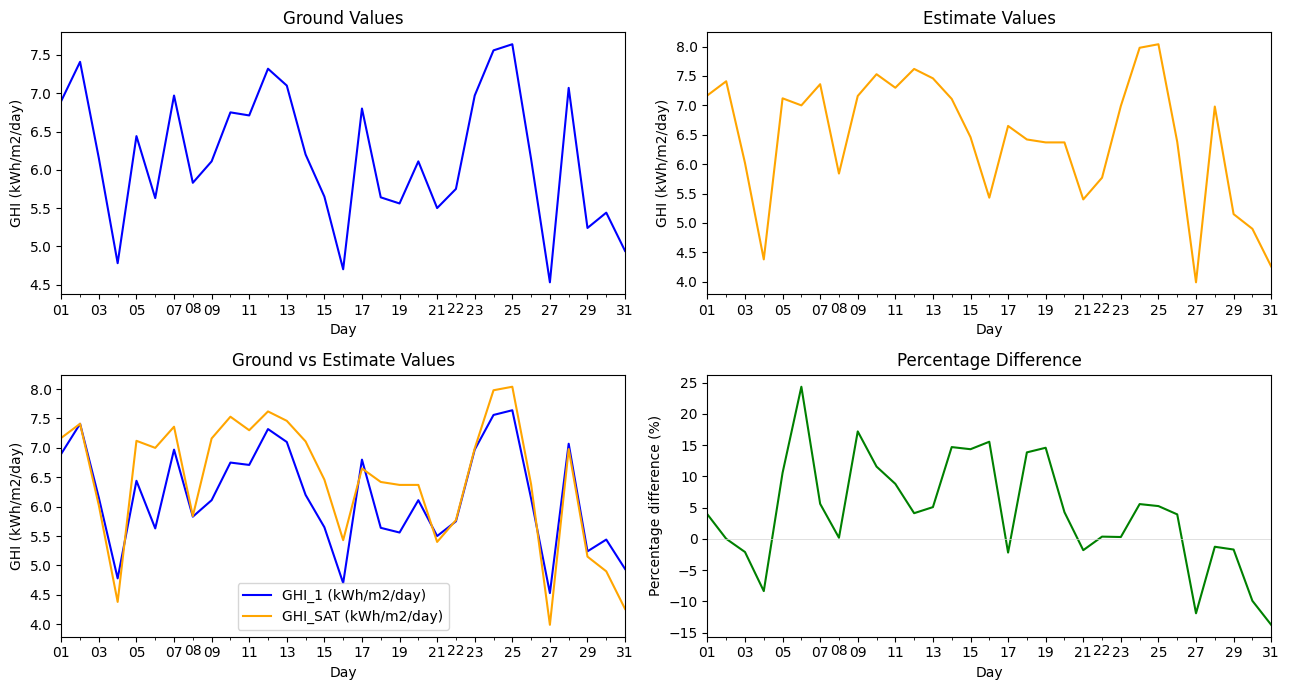

In [9]:
plot_ground_vs_estimate(ghi_ground, ghi_solargis)

# Clearsky radiation

In [10]:
# end = "2021-03-31 23:00"
times = pd.date_range(start=start, end="2021-03-31 23:00", freq='1h', tz='UTC')


In [11]:
times

DatetimeIndex(['2021-03-01 00:00:00+00:00', '2021-03-01 01:00:00+00:00',
               '2021-03-01 02:00:00+00:00', '2021-03-01 03:00:00+00:00',
               '2021-03-01 04:00:00+00:00', '2021-03-01 05:00:00+00:00',
               '2021-03-01 06:00:00+00:00', '2021-03-01 07:00:00+00:00',
               '2021-03-01 08:00:00+00:00', '2021-03-01 09:00:00+00:00',
               ...
               '2021-03-31 14:00:00+00:00', '2021-03-31 15:00:00+00:00',
               '2021-03-31 16:00:00+00:00', '2021-03-31 17:00:00+00:00',
               '2021-03-31 18:00:00+00:00', '2021-03-31 19:00:00+00:00',
               '2021-03-31 20:00:00+00:00', '2021-03-31 21:00:00+00:00',
               '2021-03-31 22:00:00+00:00', '2021-03-31 23:00:00+00:00'],
              dtype='datetime64[ns, UTC]', length=744, freq='h')

In [12]:
def convert_to_kwh_per_m2_per_day(ghi):
    ghi_daily = ghi.resample('D').sum()
    ghi_daily = ghi_daily / 1000
    ghi_daily.index = pd.to_datetime(ghi_daily.index.strftime('%Y-%m-%d'))
    return ghi_daily

### Ineichen

In [13]:
ineichen = soroti.get_clearsky(times)
ineichen.tail(20)

,ghi,dni,dhi
2021-03-31 04:00:00+00:00,6.687080,38.784364,4.730600
2021-03-31 05:00:00+00:00,239.137357,569.975886,65.989619
2021-03-31 06:00:00+00:00,520.913332,776.437542,102.314203
2021-03-31 07:00:00+00:00,766.569108,865.765634,127.526758
2021-03-31 08:00:00+00:00,952.048629,909.850738,144.981074
2021-03-31 09:00:00+00:00,1062.824971,930.443574,155.026091
2021-03-31 10:00:00+00:00,1090.722504,935.108253,157.523165
2021-03-31 11:00:00+00:00,1033.730686,925.367292,152.409421
2021-03-31 12:00:00+00:00,895.991882,897.973142,139.802217
2021-03-31 13:00:00+00:00,687.817616,842.014650,119.778137


In [14]:
ghi_in = convert_to_kwh_per_m2_per_day(ineichen['ghi'])

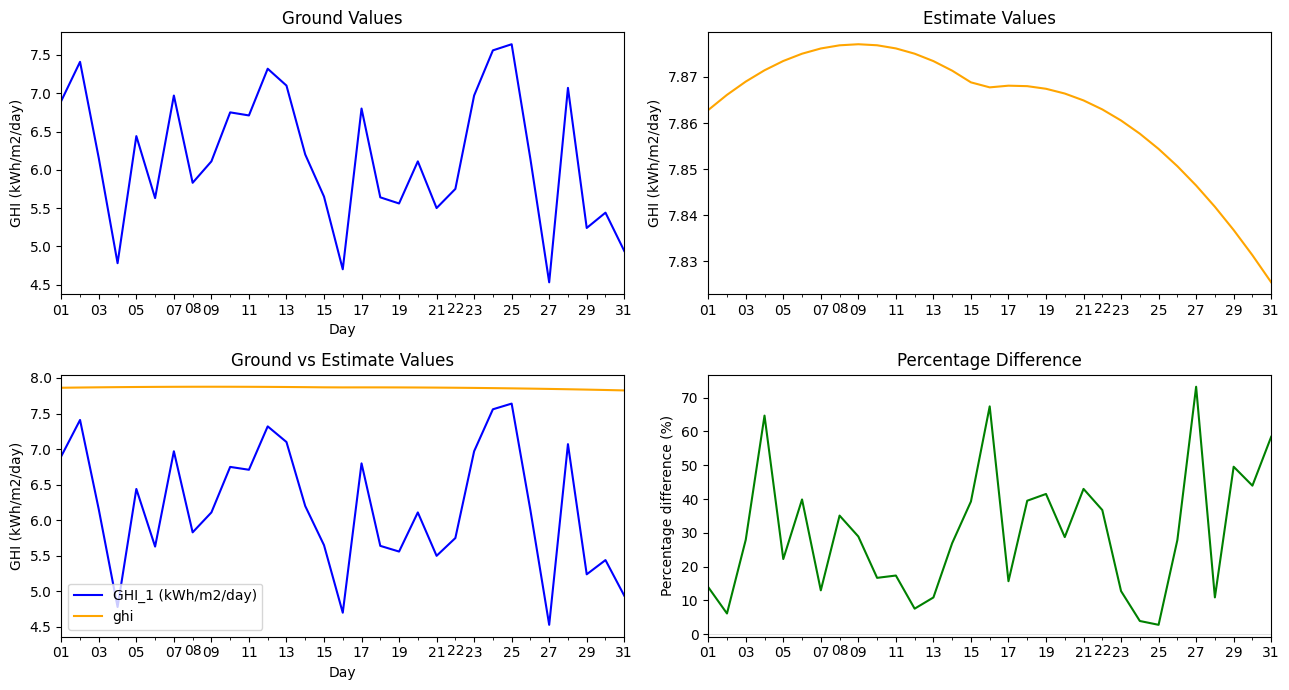

In [15]:
plot_ground_vs_estimate(ghi_ground, ghi_in)

### Simplified_Solis

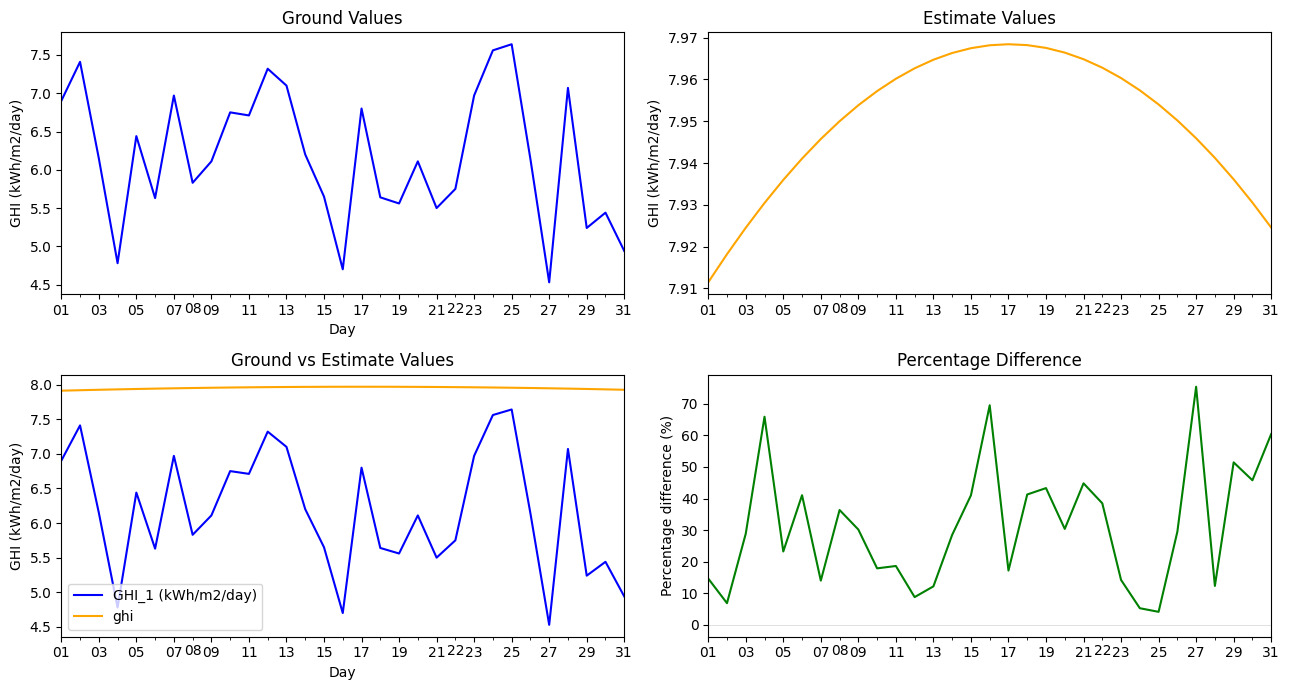

In [16]:
simplified_solis = soroti.get_clearsky(times, model='simplified_solis')
plot_ground_vs_estimate(ghi_ground, convert_to_kwh_per_m2_per_day(simplified_solis['ghi']))

### Haurwitz

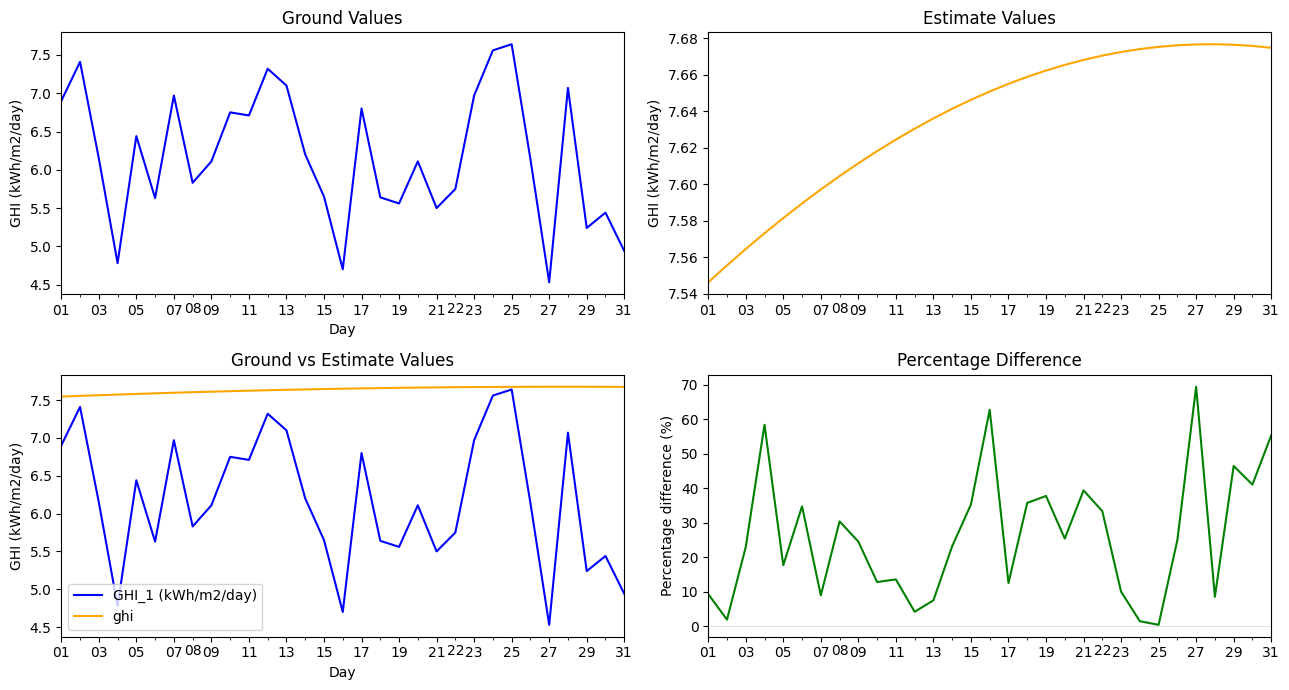

In [17]:
haurwitz = soroti.get_clearsky(times, model='haurwitz')
plot_ground_vs_estimate(ghi_ground, convert_to_kwh_per_m2_per_day(haurwitz['ghi']))

# Nrel

In [20]:
import zipfile, os
def process_data(year, location):
    zip_filename = f"{year}_{location}.zip"
    extract_path = f"{year}_{location}"
    with zipfile.ZipFile(zip_filename, "r") as zip_ref:
        zip_ref.extractall(extract_path)

    csv_filename = f'{extract_path}/{os.listdir(extract_path)[0]}/{location}_0.33_32.58_{year}.csv'
    data = pd.read_csv(csv_filename, skiprows=2)
    data['Date Local'] = pd.to_datetime(data[['Year', 'Month', 'Day', 'Hour', 'Minute']].assign(Day=lambda x: x.Day.astype(str).str.zfill(2)))
    data.drop(columns=['Year', 'Month', 'Day', 'Hour', 'Minute'], inplace=True)
    data.set_index('Date Local', inplace=True)
    return data

In [30]:
import numpy as np
import pandas as pd

def resample_to_daily(df):
    """
    Resamples a 30-minute interval dataset to daily resolution with appropriate aggregation for each parameter.
    
    Parameters:
    df (pd.DataFrame): DataFrame with a DateTime index at 30-minute intervals.

    Returns:
    pd.DataFrame: Resampled DataFrame at daily resolution.
    """
    
    # Define aggregation methods
    sum_cols = ['Clearsky DHI', 'Clearsky DNI', 'Clearsky GHI', 'DHI', 'DNI', 'GHI']
    mean_cols = ['Solar Zenith Angle', 'Surface Albedo', 'Precipitable Water', 'Dew Point', 
                 'Relative Humidity', 'Pressure', 'Temperature', 'Wind Speed']
    mode_cols = ['Cloud Type', 'Fill Flag']
    wind_direction_col = 'Wind Direction'  # Special handling for wind direction
    
    # Resample using appropriate aggregation methods
    df_daily = pd.DataFrame(index=df.resample('D').mean().index)  # Create new daily index
    
    # Sum for cumulative parameters
    df_daily[sum_cols] = df[sum_cols].resample('D').sum()
    
    # Mean for continuous parameters
    df_daily[mean_cols] = df[mean_cols].resample('D').mean()
    
    # Mode for categorical parameters
    for col in mode_cols:
        df_daily[col] = df[col].resample('D').agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan)
    
    # Vector mean for wind direction
    def vector_mean_direction(series):
        radians = np.deg2rad(series.dropna())  # Convert degrees to radians
        sin_mean = np.mean(np.sin(radians))
        cos_mean = np.mean(np.cos(radians))
        return np.rad2deg(np.arctan2(sin_mean, cos_mean)) % 360  # Convert back to degrees

    df_daily[wind_direction_col] = df[wind_direction_col].resample('D').apply(vector_mean_direction)

    return df_daily


In [55]:
nrel = process_data(2021, '1788603')
    # ghi_daily = ghi.resample('D').sum()
    # ghi_daily = ghi_daily / 1000
    # ghi_daily.index = pd.to_datetime(ghi_daily.index.strftime('%Y-%m-%d'))
nrel = nrel.loc[start:end]
nrel = nrel[nrel.index.minute == 0]
nrel

,Solar Zenith Angle,Surface Albedo,Precipitable Water,Clearsky DHI,Clearsky DNI,Clearsky GHI,Cloud Type,Dew Point,Relative Humidity,Pressure,DHI,DNI,Fill Flag,GHI,Temperature,Wind Direction,Wind Speed
Date Local,,,,,,,,,,,,,,,,,
2021-03-01 00:00:00,149.72,0.14,3.1,0,0,0,3,18.4,81.60,878,0,0,0,0,21.7,313,0.8
2021-03-01 01:00:00,135.07,0.14,3.1,0,0,0,0,18.2,82.07,878,0,0,0,0,21.4,314,0.9
2021-03-01 02:00:00,120.27,0.14,3.0,0,0,0,0,17.9,80.96,879,0,0,0,0,21.3,308,0.9
2021-03-01 03:00:00,105.42,0.14,3.0,0,0,0,0,17.6,80.14,879,0,0,0,0,21.2,299,0.7
2021-03-01 04:00:00,90.07,0.14,3.0,0,0,0,0,18.5,81.41,880,0,0,0,0,21.8,281,0.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-03-31 19:00:00,136.36,0.16,3.9,0,0,0,7,18.8,91.99,881,0,0,0,0,20.1,207,1.5
2021-03-31 20:00:00,151.21,0.16,3.9,0,0,0,6,18.7,91.62,881,0,0,0,0,20.1,210,1.4
2021-03-31 21:00:00,165.76,0.16,3.8,0,0,0,7,18.6,91.74,880,0,0,0,0,20.0,212,1.4


# REST2
```bash
pip install git+https://github.com/NREL/rest2.git
```
Importing rest2 from github
```bash
pip install h5py NREL-farms 
```
These are requirements for the rest2 library

## Input Parameters

`p` : `np.ndarray`
- Surface pressure (mbar). (mbar is the same as hPa)

`albedo` : `np.ndarray`
- Ground albedo.

`ssa` : `np.ndarray`
- Aerosol single-scattering albedo at a representative wavelength of about 700 nm.  
- Use `-9.99` or any other **negative** value if unknown (defaults to `0.92` if a negative value is input).

`g` : `np.ndarray`
- Aerosol asymmetry parameter.  
- Since it varies with wavelength and alpha, use a representative value for a wavelength of about 700 nm and alpha around 1.  
- Defaults to `0.7` if a **negative** value is input (when exact value is unknown).

`z` : `np.ndarray`
- Solar zenith angle (degrees).  
- Must represent the **average value** over the integration period (e.g., hourly).

`radius` : `np.ndarray`
- Sun-Earth radius vector, varies between `1.017` in **July** and `0.983` in **January**.

`alpha` : `np.ndarray`
- Angstrom wavelength exponent, ideally obtained by **linear regression** of all available spectral AODs between `380` and `1020` nm.  
- The input value must be within **[0, 2.5]** and will be corrected if necessary.

`beta` : `np.ndarray`
- Angstrom turbidity coefficient, i.e., **AOD at 1000 nm**.  
- The input value must be within **[0, 2.2]** and will be corrected if necessary.  
- Can be calculated as:

  \[
  \beta = \text{aod} \times (0.55)^{\alpha}
  \]

`ozone` : `np.ndarray`
- Reduced ozone vertical pathlength (atm-cm).  
- **Note:** `1 atm-cm = 1000 DU`.

`w` : `np.ndarray`
- Total precipitable water (cm).

`sza_lim` : `float | int`
- Upper limit for **solar zenith angle** (degrees).  
- SZA values **greater than this limit** will be truncated at this value.


In [56]:
from farms.utilities import ti_to_radius, calc_beta, dark_night
from rest2 import TESTDATADIR
from rest2.rest2 import rest2, rest2_tddclr, rest2_tuuclr

In [57]:
t_pressure = nrel['Pressure'].to_numpy()
t_albedo = nrel['Surface Albedo'].to_numpy()
t_w = nrel['Precipitable Water'].to_numpy()
# single scattrering albedo is not in the dataset. I have fixed it to 0.9265 at the lenght of times 
t_ssa = np.full(len(nrel.index), 0.9265)
# aerosol assymetry parameter is not in the dataset. I have fixed it to 0.7 at the lenght of times
t_g = np.full(len(nrel.index), 0.7)
t_z = nrel['Solar Zenith Angle'].to_numpy()
t_aod = np.full(len(nrel.index), 0.1398)
t_alpha = np.full(len(nrel.index), 1.2978)
t_ozone = np.full(len(nrel.index), 0.3054)
t_ti = nrel.index

print(t_pressure.shape, t_albedo.shape, t_ssa.shape, t_g.shape, t_z.shape, t_aod.shape, t_alpha.shape, t_ozone.shape, t_ti.shape)

(744,) (744,) (744,) (744,) (744,) (744,) (744,) (744,) (744,)


In [58]:
# calculate the radius and beta
radius = ti_to_radius(t_ti)
beta = calc_beta(t_aod, t_alpha)

In [59]:
t_pressure_3 = np.tile(t_pressure[:, np.newaxis], (1, 3))
t_albedo_3 = np.tile(t_albedo[:, np.newaxis], (1, 3))
t_w_3 = np.tile(t_w[:, np.newaxis], (1, 3))
t_z_3 = np.tile(t_z[:, np.newaxis], (1, 3))
t_aod_3 = np.tile(t_aod[:, np.newaxis], (1, 3))
t_ssa_3 = np.tile(t_ssa[:, np.newaxis], (1, 3))
t_g_3 = np.tile(t_g[:, np.newaxis], (1, 3))
t_alpha_3 = np.tile(t_alpha[:, np.newaxis], (1, 3))
t_ozone_3 = np.tile(t_ozone[:, np.newaxis], (1, 3))

print(t_pressure_3.shape, t_albedo_3.shape, t_w_3.shape, t_z_3.shape, t_aod_3.shape, t_ssa_3.shape, t_g_3.shape, t_alpha_3.shape, t_ozone_3.shape, t_ti.shape)

(744, 3) (744, 3) (744, 3) (744, 3) (744, 3) (744, 3) (744, 3) (744, 3) (744, 3) (744,)


In [60]:
# Calculate additional required parameters
t_radius_3 = ti_to_radius(t_ti, n_cols=t_pressure_3.shape[1])
t_beta_3 = calc_beta(t_aod_3, t_alpha_3)

In [61]:
# Run the REST2 model predictions
t_rest_data_3 = rest2(t_pressure_3, t_albedo_3, t_ssa_3, t_g_3, t_z_3, t_radius_3, t_alpha_3, t_beta_3, t_ozone_3, t_w_3)

# Apply dark night adjustment
t_rest_data_3.dhi = dark_night(t_rest_data_3.dhi, t_z_3)
t_rest_data_3.dni = dark_night(t_rest_data_3.dni, t_z_3)
t_rest_data_3.ghi = dark_night(t_rest_data_3.ghi, t_z_3)

(744,)


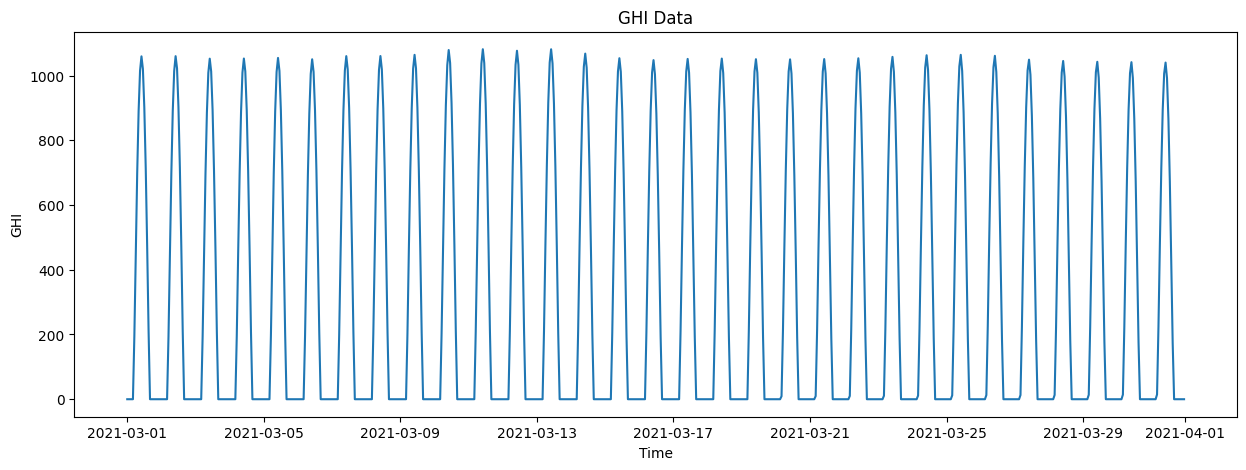

In [63]:
# make rest_data a pd Series
rest_ghi = pd.Series(t_rest_data_3.ghi[:, 2], index=t_ti)
plt.figure(figsize=(15, 5))
# Print the shape of rest_data.ghi
print(rest_ghi.shape)

# Plot the rest_data.ghi data
plt.plot(t_ti, rest_ghi)
plt.xlabel("Time")
plt.ylabel("GHI")
plt.title("GHI Data")
plt.show()

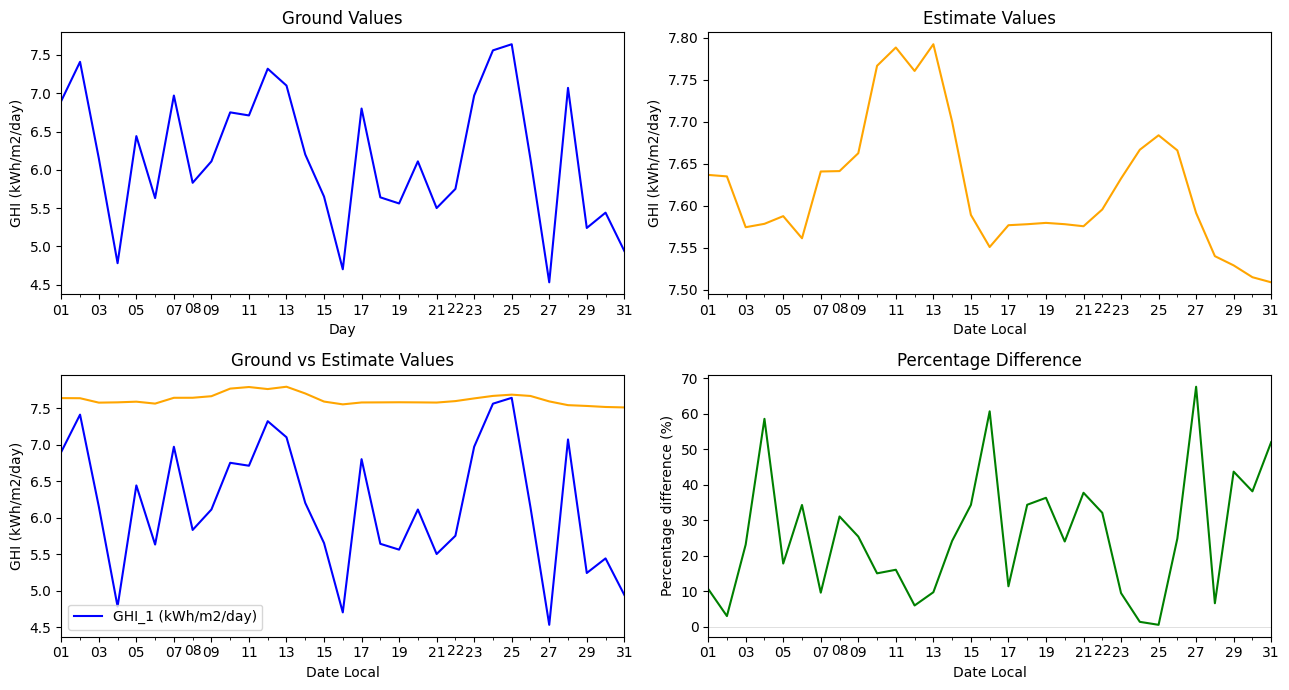

In [64]:
plot_ground_vs_estimate(ghi_ground, convert_to_kwh_per_m2_per_day(rest_ghi))

In [ ]:
import requests
import pandas as pd
import urllib.parse
import time

API_KEY = "{{YOUR_API_KEY}}"
EMAIL = "mukiibirogerz@gmail.com"
BASE_URL = "https://developer.nrel.gov/api/nsrdb/v2/solar/nsrdb-msg-v1-0-0-download.json?"
POINTS = [
'1645883,1645884,1645885,1645886,1645887,1645888,1645889,1645890,1645891,1645892,1645893,1645894,1645895,1645896,1645897,1645898,1645899,1645900,1645901,1645902,1645903,1645904,1645905,1645906,1645907,1645908,1645909,1645910,1645911,1645912,1645913,1645914,1645915,1645916,1645917,1645918,1645919,1645920,1645921,1645922,1645923,1645924,1645925,1645926,1645927,1645928,1645929,1645930,1645931,1645932,1645933,1645934,1645935,1645936,1645937,1645938,1645939,1645940,1645941,1645942,1645943,1645944,1645945,1645946,1645947,1645948,1645949,1645950,1645951,1645952,1645953,1645954,1645955,1645956,1645957,1645958,1645959,1645960,1645961,1645962,1645963,1645964,1645965,1645966,1645967,1645968,1645969,1645970,1645971,1645972,1645973,1645974,1645975,1645976,1645977,1645978,1645979,1645980,1645981,1645982,1645983,1645984,1645985,1645986,1645987,1645988,1645989,1645990,1645991,1645992,1645993,1645994,1645995,1645996,1645997,1645998,1645999,1646000,1646001,1646002,1646003,1646004,1646005,1646006,1646007,1646008,1646009,1647981,1647982,1647983,1647984,1647985,1647986,1647987,1647988,1647989,1647990,1647991,1647992,1647993,1647994,1647995,1647996,1647997,1647998,1647999,1648000,1648001,1648002,1648003,1648004,1648005,1648006,1648007,1648008,1648009,1648010,1648011,1648012,1648013,1648014,1648015,1648016,1648017,1648018,1648019,1648020,1648021,1648022,1648023,1648024,1648025,1648026,1648027,1648028,1648029,1648030,1648031,1648032,1648033,1648034,1648035,1648036,1648037,1648038,1648039,1648040,1648041,1648042,1648043,1648044,1648045,1648046,1648047,1648048,1648049,1648050,1648051,1648052,1648053',
'1648054,1648055,1648056,1648057,1648058,1648059,1648060,1648061,1648062,1648063,1648064,1648065,1648066,1648067,1648068,1648069,1648070,1648071,1648072,1648073,1648074,1648075,1648076,1648077,1648078,1648079,1648080,1648081,1648082,1648083,1648084,1648085,1648086,1648087,1648088,1648089,1648090,1648091,1648092,1648093,1648094,1648095,1648096,1648097,1648098,1648099,1648100,1648101,1648102,1648103,1648104,1648105,1648106,1648107,1650077,1650078,1650079,1650080,1650081,1650082,1650083,1650084,1650085,1650086,1650087,1650088,1650089,1650090,1650091,1650092,1650093,1650094,1650095,1650096,1650097,1650098,1650099,1650100,1650101,1650102,1650103,1650104,1650105,1650106,1650107,1650108,1650109,1650110,1650111,1650112,1650113,1650114,1650115,1650116,1650117,1650118,1650119,1650120,1650121,1650122,1650123,1650124,1650125,1650126,1650127,1650128,1650129,1650130,1650131,1650132,1650133,1650134,1650135,1650136,1650137,1650138,1650139,1650140,1650141,1650142,1650143,1650144,1650145,1650146,1650147,1650148,1650149,1650150,1650151,1650152,1650153,1650154,1650155,1650156,1650157,1650158,1650159,1650160,1650161,1650162,1650163,1650164,1650165,1650166,1650167,1650168,1650169,1650170,1650171,1650172,1650173,1650174,1650175,1650176,1650177,1650178,1650179,1650180,1650181,1650182,1650183,1650184,1650185,1650186,1650187,1650188,1650189,1650190,1650191,1650192,1650193,1650194,1650195,1650196,1650197,1650198,1650199,1650200,1650201,1650202,1650203,1652166,1652167,1652168,1652169,1652170,1652171,1652172,1652173,1652174,1652175,1652176,1652177,1652178,1652179,1652180,1652181,1652182,1652183,1652184',
'1652185,1652186,1652187,1652188,1652189,1652190,1652191,1652192,1652193,1652194,1652195,1652196,1652197,1652198,1652199,1652200,1652201,1652202,1652203,1652204,1652205,1652206,1652207,1652208,1652209,1652210,1652211,1652212,1652213,1652214,1652215,1652216,1652217,1652218,1652219,1652220,1652221,1652222,1652223,1652224,1652225,1652226,1652227,1652228,1652229,1652230,1652231,1652232,1652233,1652234,1652235,1652236,1652237,1652238,1652239,1652240,1652241,1652242,1652243,1652244,1652245,1652246,1652247,1652248,1652249,1652250,1652251,1652252,1652253,1652254,1652255,1652256,1652257,1652258,1652259,1652260,1652261,1652262,1652263,1652264,1652265,1652266,1652267,1652268,1652269,1652270,1652271,1652272,1652273,1652274,1652275,1652276,1652277,1652278,1652279,1652280,1652281,1652282,1652283,1652284,1652285,1652286,1652287,1652288,1652289,1652290,1652291,1652292,1654253,1654254,1654255,1654256,1654257,1654258,1654259,1654260,1654261,1654262,1654263,1654264,1654265,1654266,1654267,1654268,1654269,1654270,1654271,1654272,1654273,1654274,1654275,1654276,1654277,1654278,1654279,1654280,1654281,1654282,1654283,1654284,1654285,1654286,1654287,1654288,1654289,1654290,1654291,1654292,1654293,1654294,1654295,1654296,1654297,1654298,1654299,1654300,1654301,1654302,1654303,1654304,1654305,1654306,1654307,1654308,1654309,1654310,1654311,1654312,1654313,1654314,1654315,1654316,1654317,1654318,1654319,1654320,1654321,1654322,1654323,1654324,1654325,1654326,1654327,1654328,1654329,1654330,1654331,1654332,1654333,1654334,1654335,1654336,1654337,1654338,1654339,1654340,1654341,1654342,1654343,1654344',
'1654345,1654346,1654347,1654348,1654349,1654350,1654351,1654352,1654353,1654354,1654355,1654356,1654357,1654358,1654359,1654360,1654361,1654362,1654363,1654364,1654365,1654366,1654367,1654368,1654369,1654370,1654371,1654372,1654373,1654374,1654375,1654376,1654377,1654378,1654379,1656338,1656339,1656340,1656341,1656342,1656343,1656344,1656345,1656346,1656347,1656348,1656349,1656350,1656351,1656352,1656353,1656354,1656355,1656356,1656357,1656358,1656359,1656360,1656361,1656362,1656363,1656364,1656365,1656366,1656367,1656368,1656369,1656370,1656371,1656372,1656373,1656374,1656375,1656376,1656377,1656378,1656379,1656380,1656381,1656382,1656383,1656384,1656385,1656386,1656387,1656388,1656389,1656390,1656391,1656392,1656393,1656394,1656395,1656396,1656397,1656398,1656399,1656400,1656401,1656402,1656403,1656404,1656405,1656406,1656407,1656408,1656409,1656410,1656411,1656412,1656413,1656414,1656415,1656416,1656417,1656418,1656419,1656420,1656421,1656422,1656423,1656424,1656425,1656426,1656427,1656428,1656429,1656430,1656431,1656432,1656433,1656434,1656435,1656436,1656437,1656438,1656439,1656440,1656441,1656442,1656443,1656444,1656445,1656446,1656447,1656448,1656449,1656450,1656451,1656452,1656453,1656454,1656455,1656456,1656457,1656458,1656459,1656460,1656461,1656462,1656463,1656464,1658417,1658418,1658419,1658420,1658421,1658422,1658423,1658424,1658425,1658426,1658427,1658428,1658429,1658430,1658431,1658432,1658433,1658434,1658435,1658436,1658437,1658438,1658439,1658440,1658441,1658442,1658443,1658444,1658445,1658446,1658447,1658448,1658449,1658450,1658451,1658452,1658453,1658454',
'1658455,1658456,1658457,1658458,1658459,1658460,1658461,1658462,1658463,1658464,1658465,1658466,1658467,1658468,1658469,1658470,1658471,1658472,1658473,1658474,1658475,1658476,1658477,1658478,1658479,1658480,1658481,1658482,1658483,1658484,1658485,1658486,1658487,1658488,1658489,1658490,1658491,1658492,1658493,1658494,1658495,1658496,1658497,1658498,1658499,1658500,1658501,1658502,1658503,1658504,1658505,1658506,1658507,1658508,1658509,1658510,1658511,1658512,1658513,1658514,1658515,1658516,1658517,1658518,1658519,1658520,1658521,1658522,1658523,1658524,1658525,1658526,1658527,1658528,1658529,1658530,1658531,1658532,1658533,1658534,1658535,1658536,1658537,1658538,1658539,1658540,1658541,1658542,1658543,1660492,1660493,1660494,1660495,1660496,1660497,1660498,1660499,1660500,1660501,1660502,1660503,1660504,1660505,1660506,1660507,1660508,1660509,1660510,1660511,1660512,1660513,1660514,1660515,1660516,1660517,1660518,1660519,1660520,1660521,1660522,1660523,1660524,1660525,1660526,1660527,1660528,1660529,1660530,1660531,1660532,1660533,1660534,1660535,1660536,1660537,1660538,1660539,1660540,1660541,1660542,1660543,1660544,1660545,1660546,1660547,1660548,1660549,1660550,1660551,1660552,1660553,1660554,1660555,1660556,1660557,1660558,1660559,1660560,1660561,1660562,1660563,1660564,1660565,1660566,1660567,1660568,1660569,1660570,1660571,1660572,1660573,1660574,1660575,1660576,1660577,1660578,1660579,1660580,1660581,1660582,1660583,1660584,1660585,1660586,1660587,1660588,1660589,1660590,1660591,1660592,1660593,1660594,1660595,1660596,1660597,1660598,1660599,1660600,1660601,1660602',
'1660603,1660604,1660605,1660606,1660607,1660608,1660609,1660610,1660611,1660612,1660613,1660614,1660615,1660616,1660617,1660618,1662566,1662567,1662568,1662569,1662570,1662571,1662572,1662573,1662574,1662575,1662576,1662577,1662578,1662579,1662580,1662581,1662582,1662583,1662584,1662585,1662586,1662587,1662588,1662589,1662590,1662591,1662592,1662593,1662594,1662595,1662596,1662597,1662598,1662599,1662600,1662601,1662602,1662603,1662604,1662605,1662606,1662607,1662608,1662609,1662610,1662611,1662612,1662613,1662614,1662615,1662616,1662617,1662618,1662619,1662620,1662621,1662622,1662623,1662624,1662625,1662626,1662627,1662628,1662629,1662630,1662631,1662632,1662633,1662634,1662635,1662636,1662637,1662638,1662639,1662640,1662641,1662642,1662643,1662644,1662645,1662646,1662647,1662648,1662649,1662650,1662651,1662652,1662653,1662654,1662655,1662656,1662657,1662658,1662659,1662660,1662661,1662662,1662663,1662664,1662665,1662666,1662667,1662668,1662669,1662670,1662671,1662672,1662673,1662674,1662675,1662676,1662677,1662678,1662679,1662680,1662681,1662682,1662683,1662684,1662685,1662686,1662687,1662688,1662689,1662690,1662691,1662692,1664637,1664638,1664639,1664640,1664641,1664642,1664643,1664644,1664645,1664646,1664647,1664648,1664649,1664650,1664651,1664652,1664653,1664654,1664655,1664656,1664657,1664658,1664659,1664660,1664661,1664662,1664663,1664664,1664665,1664666,1664667,1664668,1664669,1664670,1664671,1664672,1664673,1664674,1664675,1664676,1664677,1664678,1664679,1664680,1664681,1664682,1664683,1664684,1664685,1664686,1664687,1664688,1664689,1664690,1664691,1664692,1664693',
'1664694,1664695,1664696,1664697,1664698,1664699,1664700,1664701,1664702,1664703,1664704,1664705,1664706,1664707,1664708,1664709,1664710,1664711,1664712,1664713,1664714,1664715,1664716,1664717,1664718,1664719,1664720,1664721,1664722,1664723,1664724,1664725,1664726,1664727,1664728,1664729,1664730,1664731,1664732,1664733,1664734,1664735,1664736,1664737,1664738,1664739,1664740,1664741,1664742,1664743,1664744,1664745,1664746,1664747,1664748,1664749,1664750,1664751,1664752,1664753,1664754,1664755,1664756,1664757,1664758,1664759,1664760,1664761,1664762,1664763,1666708,1666709,1666710,1666711,1666712,1666713,1666714,1666715,1666716,1666717,1666718,1666719,1666720,1666721,1666722,1666723,1666724,1666725,1666726,1666727,1666728,1666729,1666730,1666731,1666732,1666733,1666734,1666735,1666736,1666737,1666738,1666739,1666740,1666741,1666742,1666743,1666744,1666745,1666746,1666747,1666748,1666749,1666750,1666751,1666752,1666753,1666754,1666755,1666756,1666757,1666758,1666759,1666760,1666761,1666762,1666763,1666764,1666765,1666766,1666767,1666768,1666769,1666770,1666771,1666772,1666773,1666774,1666775,1666776,1666777,1666778,1666779,1666780,1666781,1666782,1666783,1666784,1666785,1666786,1666787,1666788,1666789,1666790,1666791,1666792,1666793,1666794,1666795,1666796,1666797,1666798,1666799,1666800,1666801,1666802,1666803,1666804,1666805,1666806,1666807,1666808,1666809,1666810,1666811,1666812,1666813,1666814,1666815,1666816,1666817,1666818,1666819,1666820,1666821,1666822,1666823,1666824,1666825,1666826,1666827,1666828,1666829,1666830,1666831,1666832,1666833,1666834,1668780,1668781,1668782',
'1668783,1668784,1668785,1668786,1668787,1668788,1668789,1668790,1668791,1668792,1668793,1668794,1668795,1668796,1668797,1668798,1668799,1668800,1668801,1668802,1668803,1668804,1668805,1668806,1668807,1668808,1668809,1668810,1668811,1668812,1668813,1668814,1668815,1668816,1668817,1668818,1668819,1668820,1668821,1668822,1668823,1668824,1668825,1668826,1668827,1668828,1668829,1668830,1668831,1668832,1668833,1668834,1668835,1668836,1668837,1668838,1668839,1668840,1668841,1668842,1668843,1668844,1668845,1668846,1668847,1668848,1668849,1668850,1668851,1668852,1668853,1668854,1668855,1668856,1668857,1668858,1668859,1668860,1668861,1668862,1668863,1668864,1668865,1668866,1668867,1668868,1668869,1668870,1668871,1668872,1668873,1668874,1668875,1668876,1668877,1668878,1668879,1668880,1668881,1668882,1668883,1668884,1668885,1668886,1668887,1668888,1668889,1668890,1668891,1668892,1668893,1668894,1668895,1668896,1668897,1668898,1668899,1668900,1668901,1668902,1668903,1668904,1668905,1668906,1670850,1670851,1670852,1670853,1670854,1670855,1670856,1670857,1670858,1670859,1670860,1670861,1670862,1670863,1670864,1670865,1670866,1670867,1670868,1670869,1670870,1670871,1670872,1670873,1670874,1670875,1670876,1670877,1670878,1670879,1670880,1670881,1670882,1670883,1670884,1670885,1670886,1670887,1670888,1670889,1670890,1670891,1670892,1670893,1670894,1670895,1670896,1670897,1670898,1670899,1670900,1670901,1670902,1670903,1670904,1670905,1670906,1670907,1670908,1670909,1670910,1670911,1670912,1670913,1670914,1670915,1670916,1670917,1670918,1670919,1670920,1670921,1670922,1670923,1670924,1670925',
'1670926,1670927,1670928,1670929,1670930,1670931,1670932,1670933,1670934,1670935,1670936,1670937,1670938,1670939,1670940,1670941,1670942,1670943,1670944,1670945,1670946,1670947,1670948,1670949,1670950,1670951,1670952,1670953,1670954,1670955,1670956,1670957,1670958,1670959,1670960,1670961,1670962,1670963,1670964,1670965,1670966,1670967,1670968,1670969,1670970,1670971,1670972,1670973,1670974,1670975,1670976,1672920,1672921,1672922,1672923,1672924,1672925,1672926,1672927,1672928,1672929,1672930,1672931,1672932,1672933,1672934,1672935,1672936,1672937,1672938,1672939,1672940,1672941,1672942,1672943,1672944,1672945,1672946,1672947,1672948,1672949,1672950,1672951,1672952,1672953,1672954,1672955,1672956,1672957,1672958,1672959,1672960,1672961,1672962,1672963,1672964,1672965,1672966,1672967,1672968,1672969,1672970,1672971,1672972,1672973,1672974,1672975,1672976,1672977,1672978,1672979,1672980,1672981,1672982,1672983,1672984,1672985,1672986,1672987,1672988,1672989,1672990,1672991,1672992,1672993,1672994,1672995,1672996,1672997,1672998,1672999,1673000,1673001,1673002,1673003,1673004,1673005,1673006,1673007,1673008,1673009,1673010,1673011,1673012,1673013,1673014,1673015,1673016,1673017,1673018,1673019,1673020,1673021,1673022,1673023,1673024,1673025,1673026,1673027,1673028,1673029,1673030,1673031,1673032,1673033,1673034,1673035,1673036,1673037,1673038,1673039,1673040,1673041,1673042,1673043,1673044,1673045,1673046,1674988,1674989,1674990,1674991,1674992,1674993,1674994,1674995,1674996,1674997,1674998,1674999,1675000,1675001,1675002,1675003,1675004,1675005,1675006,1675007,1675008,1675009',
'1675010,1675011,1675012,1675013,1675014,1675015,1675016,1675017,1675018,1675019,1675020,1675021,1675022,1675023,1675024,1675025,1675026,1675027,1675028,1675029,1675030,1675031,1675032,1675033,1675034,1675035,1675036,1675037,1675038,1675039,1675040,1675041,1675042,1675043,1675044,1675045,1675046,1675047,1675048,1675049,1675050,1675051,1675052,1675053,1675054,1675055,1675056,1675057,1675058,1675059,1675060,1675061,1675062,1675063,1675064,1675065,1675066,1675067,1675068,1675069,1675070,1675071,1675072,1675073,1675074,1675075,1675076,1675077,1675078,1675079,1675080,1675081,1675082,1675083,1675084,1675085,1675086,1675087,1675088,1675089,1675090,1675091,1675092,1675093,1675094,1675095,1675096,1675097,1675098,1675099,1675100,1675101,1675102,1675103,1675104,1675105,1675106,1675107,1675108,1675109,1675110,1675111,1675112,1675113,1675114,1677055,1677056,1677057,1677058,1677059,1677060,1677061,1677062,1677063,1677064,1677065,1677066,1677067,1677068,1677069,1677070,1677071,1677072,1677073,1677074,1677075,1677076,1677077,1677078,1677079,1677080,1677081,1677082,1677083,1677084,1677085,1677086,1677087,1677088,1677089,1677090,1677091,1677092,1677093,1677094,1677095,1677096,1677097,1677098,1677099,1677100,1677101,1677102,1677103,1677104,1677105,1677106,1677107,1677108,1677109,1677110,1677111,1677112,1677113,1677114,1677115,1677116,1677117,1677118,1677119,1677120,1677121,1677122,1677123,1677124,1677125,1677126,1677127,1677128,1677129,1677130,1677131,1677132,1677133,1677134,1677135,1677136,1677137,1677138,1677139,1677140,1677141,1677142,1677143,1677144,1677145,1677146,1677147,1677148,1677149',
'1677150,1677151,1677152,1677153,1677154,1677155,1677156,1677157,1677158,1677159,1677160,1677161,1677162,1677163,1677164,1677165,1677166,1677167,1677168,1677169,1677170,1677171,1677172,1677173,1677174,1677175,1677176,1677177,1677178,1677179,1677180,1677181,1679120,1679121,1679122,1679123,1679124,1679125,1679126,1679127,1679128,1679129,1679130,1679131,1679132,1679133,1679134,1679135,1679136,1679137,1679138,1679139,1679140,1679141,1679142,1679143,1679144,1679145,1679146,1679147,1679148,1679149,1679150,1679151,1679152,1679153,1679154,1679155,1679156,1679157,1679158,1679159,1679160,1679161,1679162,1679163,1679164,1679165,1679166,1679167,1679168,1679169,1679170,1679171,1679172,1679173,1679174,1679175,1679176,1679177,1679178,1679179,1679180,1679181,1679182,1679183,1679184,1679185,1679186,1679187,1679188,1679189,1679190,1679191,1679192,1679193,1679194,1679195,1679196,1679197,1679198,1679199,1679200,1679201,1679202,1679203,1679204,1679205,1679206,1679207,1679208,1679209,1679210,1679211,1679212,1679213,1679214,1679215,1679216,1679217,1679218,1679219,1679220,1679221,1679222,1679223,1679224,1679225,1679226,1679227,1679228,1679229,1679230,1679231,1679232,1679233,1679234,1679235,1679236,1679237,1679238,1679239,1679240,1679241,1679242,1679243,1679244,1679245,1679246,1681182,1681183,1681184,1681185,1681186,1681187,1681188,1681189,1681190,1681191,1681192,1681193,1681194,1681195,1681196,1681197,1681198,1681199,1681200,1681201,1681202,1681203,1681204,1681205,1681206,1681207,1681208,1681209,1681210,1681211,1681212,1681213,1681214,1681215,1681216,1681217,1681218,1681219,1681220,1681221,1681222',
'1681223,1681224,1681225,1681226,1681227,1681228,1681229,1681230,1681231,1681232,1681233,1681234,1681235,1681236,1681237,1681238,1681239,1681240,1681241,1681242,1681243,1681244,1681245,1681246,1681247,1681248,1681249,1681250,1681251,1681252,1681253,1681254,1681255,1681256,1681257,1681258,1681259,1681260,1681261,1681262,1681263,1681264,1681265,1681266,1681267,1681268,1681269,1681270,1681271,1681272,1681273,1681274,1681275,1681276,1681277,1681278,1681279,1681280,1681281,1681282,1681283,1681284,1681285,1681286,1681287,1681288,1681289,1681290,1681291,1681292,1681293,1681294,1681295,1681296,1681297,1681298,1681299,1681300,1681301,1681302,1681303,1681304,1681305,1681306,1681307,1681308,1683242,1683243,1683244,1683245,1683246,1683247,1683248,1683249,1683250,1683251,1683252,1683253,1683254,1683255,1683256,1683257,1683258,1683259,1683260,1683261,1683262,1683263,1683264,1683265,1683266,1683267,1683268,1683269,1683270,1683271,1683272,1683273,1683274,1683275,1683276,1683277,1683278,1683279,1683280,1683281,1683282,1683283,1683284,1683285,1683286,1683287,1683288,1683289,1683290,1683291,1683292,1683293,1683294,1683295,1683296,1683297,1683298,1683299,1683300,1683301,1683302,1683303,1683304,1683305,1683306,1683307,1683308,1683309,1683310,1683311,1683312,1683313,1683314,1683315,1683316,1683317,1683318,1683319,1683320,1683321,1683322,1683323,1683324,1683325,1683326,1683327,1683328,1683329,1683330,1683331,1683332,1683333,1683334,1683335,1683336,1683337,1683338,1683339,1683340,1683341,1683342,1683343,1683344,1683345,1683346,1683347,1683348,1683349,1683350,1683351,1683352,1683353,1683354,1683355',
'1683356,1683357,1683358,1683359,1683360,1683361,1683362,1683363,1683364,1683365,1683366,1683367,1683368,1685300,1685301,1685302,1685303,1685304,1685305,1685306,1685307,1685308,1685309,1685310,1685311,1685312,1685313,1685314,1685315,1685316,1685317,1685318,1685319,1685320,1685321,1685322,1685323,1685324,1685325,1685326,1685327,1685328,1685329,1685330,1685331,1685332,1685333,1685334,1685335,1685336,1685337,1685338,1685339,1685340,1685341,1685342,1685343,1685344,1685345,1685346,1685347,1685348,1685349,1685350,1685351,1685352,1685353,1685354,1685355,1685356,1685357,1685358,1685359,1685360,1685361,1685362,1685363,1685364,1685365,1685366,1685367,1685368,1685369,1685370,1685371,1685372,1685373,1685374,1685375,1685376,1685377,1685378,1685379,1685380,1685381,1685382,1685383,1685384,1685385,1685386,1685387,1685388,1685389,1685390,1685391,1685392,1685393,1685394,1685395,1685396,1685397,1685398,1685399,1685400,1685401,1685402,1685403,1685404,1685405,1685406,1685407,1685408,1685409,1685410,1685411,1685412,1685413,1685414,1685415,1685416,1685417,1685418,1685419,1685420,1685421,1685422,1685423,1685424,1685425,1685426,1687354,1687355,1687356,1687357,1687358,1687359,1687360,1687361,1687362,1687363,1687364,1687365,1687366,1687367,1687368,1687369,1687370,1687371,1687372,1687373,1687374,1687375,1687376,1687377,1687378,1687379,1687380,1687381,1687382,1687383,1687384,1687385,1687386,1687387,1687388,1687389,1687390,1687391,1687392,1687393,1687394,1687395,1687396,1687397,1687398,1687399,1687400,1687401,1687402,1687403,1687404,1687405,1687406,1687407,1687408,1687409,1687410,1687411,1687412,1687413',
'1687414,1687415,1687416,1687417,1687418,1687419,1687420,1687421,1687422,1687423,1687424,1687425,1687426,1687427,1687428,1687429,1687430,1687431,1687432,1687433,1687434,1687435,1687436,1687437,1687438,1687439,1687440,1687441,1687442,1687443,1687444,1687445,1687446,1687447,1687448,1687449,1687450,1687451,1687452,1687453,1687454,1687455,1687456,1687457,1687458,1687459,1687460,1687461,1687462,1687463,1687464,1687465,1687466,1687467,1687468,1687469,1687470,1687471,1687472,1687473,1687474,1687475,1687476,1687477,1687478,1687479,1687480,1689406,1689407,1689408,1689409,1689410,1689411,1689412,1689413,1689414,1689415,1689416,1689417,1689418,1689419,1689420,1689421,1689422,1689423,1689424,1689425,1689426,1689427,1689428,1689429,1689430,1689431,1689432,1689433,1689434,1689435,1689436,1689437,1689438,1689439,1689440,1689441,1689442,1689443,1689444,1689445,1689446,1689447,1689448,1689449,1689450,1689451,1689452,1689453,1689454,1689455,1689456,1689457,1689458,1689459,1689460,1689461,1689462,1689463,1689464,1689465,1689466,1689467,1689468,1689469,1689470,1689471,1689472,1689473,1689474,1689475,1689476,1689477,1689478,1689479,1689480,1689481,1689482,1689483,1689484,1689485,1689486,1689487,1689488,1689489,1689490,1689491,1689492,1689493,1689494,1689495,1689496,1689497,1689498,1689499,1689500,1689501,1689502,1689503,1689504,1689505,1689506,1689507,1689508,1689509,1689510,1689511,1689512,1689513,1689514,1689515,1689516,1689517,1689518,1689519,1689520,1689521,1689522,1689523,1689524,1689525,1689526,1689527,1689528,1689529,1689530,1689531,1689532,1691455,1691456,1691457,1691458,1691459,1691460',
'1691461,1691462,1691463,1691464,1691465,1691466,1691467,1691468,1691469,1691470,1691471,1691472,1691473,1691474,1691475,1691476,1691477,1691478,1691479,1691480,1691481,1691482,1691483,1691484,1691485,1691486,1691487,1691488,1691489,1691490,1691491,1691492,1691493,1691494,1691495,1691496,1691497,1691498,1691499,1691500,1691501,1691502,1691503,1691504,1691505,1691506,1691507,1691508,1691509,1691510,1691511,1691512,1691513,1691514,1691515,1691516,1691517,1691518,1691519,1691520,1691521,1691522,1691523,1691524,1691525,1691526,1691527,1691528,1691529,1691530,1691531,1691532,1691533,1691534,1691535,1691536,1691537,1691538,1691539,1691540,1691541,1691542,1691543,1691544,1691545,1691546,1691547,1691548,1691549,1691550,1691551,1691552,1691553,1691554,1691555,1691556,1691557,1691558,1691559,1691560,1691561,1691562,1691563,1691564,1691565,1691566,1691567,1691568,1691569,1691570,1691571,1691572,1691573,1691574,1691575,1691576,1691577,1691578,1691579,1691580,1691581,1693499,1693500,1693501,1693502,1693503,1693504,1693505,1693506,1693507,1693508,1693509,1693510,1693511,1693512,1693513,1693514,1693515,1693516,1693517,1693518,1693519,1693520,1693521,1693522,1693523,1693524,1693525,1693526,1693527,1693528,1693529,1693530,1693531,1693532,1693533,1693534,1693535,1693536,1693537,1693538,1693539,1693540,1693541,1693542,1693543,1693544,1693545,1693546,1693547,1693548,1693549,1693550,1693551,1693552,1693553,1693554,1693555,1693556,1693557,1693558,1693559,1693560,1693561,1693562,1693563,1693564,1693565,1693566,1693567,1693568,1693569,1693570,1693571,1693572,1693573,1693574,1693575,1693576,1693577',
'1693578,1693579,1693580,1693581,1693582,1693583,1693584,1693585,1693586,1693587,1693588,1693589,1693590,1693591,1693592,1693593,1693594,1693595,1693596,1693597,1693598,1693599,1693600,1693601,1693602,1693603,1693604,1693605,1693606,1693607,1693608,1693609,1693610,1693611,1693612,1693613,1693614,1693615,1693616,1693617,1693618,1693619,1693620,1693621,1693622,1693623,1693624,1693625,1695540,1695541,1695542,1695543,1695544,1695545,1695546,1695547,1695548,1695549,1695550,1695551,1695552,1695553,1695554,1695555,1695556,1695557,1695558,1695559,1695560,1695561,1695562,1695563,1695564,1695565,1695566,1695567,1695568,1695569,1695570,1695571,1695572,1695573,1695574,1695575,1695576,1695577,1695578,1695579,1695580,1695581,1695582,1695583,1695584,1695585,1695586,1695587,1695588,1695589,1695590,1695591,1695592,1695593,1695594,1695595,1695596,1695597,1695598,1695599,1695600,1695601,1695602,1695603,1695604,1695605,1695606,1695607,1695608,1695609,1695610,1695611,1695612,1695613,1695614,1695615,1695616,1695617,1695618,1695619,1695620,1695621,1695622,1695623,1695624,1695625,1695626,1695627,1695628,1695629,1695630,1695631,1695632,1695633,1695634,1695635,1695636,1695637,1695638,1695639,1695640,1695641,1695642,1695643,1695644,1695645,1695646,1695647,1695648,1695649,1695650,1695651,1695652,1695653,1695654,1695655,1695656,1695657,1695658,1695659,1695660,1695661,1695662,1695663,1695664,1695665,1695666,1697575,1697576,1697577,1697578,1697579,1697580,1697581,1697582,1697583,1697584,1697585,1697586,1697587,1697588,1697589,1697590,1697591,1697592,1697593,1697594,1697595,1697596,1697597,1697598,1697599',
'1697600,1697601,1697602,1697603,1697604,1697605,1697606,1697607,1697608,1697609,1697610,1697611,1697612,1697613,1697614,1697615,1697616,1697617,1697618,1697619,1697620,1697621,1697622,1697623,1697624,1697625,1697626,1697627,1697628,1697629,1697630,1697631,1697632,1697633,1697634,1697635,1697636,1697637,1697638,1697639,1697640,1697641,1697642,1697643,1697644,1697645,1697646,1697647,1697648,1697649,1697650,1697651,1697652,1697653,1697654,1697655,1697656,1697657,1697658,1697659,1697660,1697661,1697662,1697663,1697664,1697665,1697666,1697667,1697668,1697669,1697670,1697671,1697672,1697673,1697674,1697675,1697676,1697677,1697678,1697679,1697680,1697681,1697682,1697683,1697684,1697685,1697686,1697687,1697688,1697689,1697690,1697691,1697692,1697693,1697694,1697695,1697696,1697697,1697698,1697699,1697700,1697701,1699604,1699605,1699606,1699607,1699608,1699609,1699610,1699611,1699612,1699613,1699614,1699615,1699616,1699617,1699618,1699619,1699620,1699621,1699622,1699623,1699624,1699625,1699626,1699627,1699628,1699629,1699630,1699631,1699632,1699633,1699634,1699635,1699636,1699637,1699638,1699639,1699640,1699641,1699642,1699643,1699644,1699645,1699646,1699647,1699648,1699649,1699650,1699651,1699652,1699653,1699654,1699655,1699656,1699657,1699658,1699659,1699660,1699661,1699662,1699663,1699664,1699665,1699666,1699667,1699668,1699669,1699670,1699671,1699672,1699673,1699674,1699675,1699676,1699677,1699678,1699679,1699680,1699681,1699682,1699683,1699684,1699685,1699686,1699687,1699688,1699689,1699690,1699691,1699692,1699693,1699694,1699695,1699696,1699697,1699698,1699699,1699700,1699701',
'1699702,1699703,1699704,1699705,1699706,1699707,1699708,1699709,1699710,1699711,1699712,1699713,1699714,1699715,1699716,1699717,1699718,1699719,1699720,1699721,1699722,1699723,1699724,1699725,1699726,1699727,1699728,1699729,1699730,1701629,1701630,1701631,1701632,1701633,1701634,1701635,1701636,1701637,1701638,1701639,1701640,1701641,1701642,1701643,1701644,1701645,1701646,1701647,1701648,1701649,1701650,1701651,1701652,1701653,1701654,1701655,1701656,1701657,1701658,1701659,1701660,1701661,1701662,1701663,1701664,1701665,1701666,1701667,1701668,1701669,1701670,1701671,1701672,1701673,1701674,1701675,1701676,1701677,1701678,1701679,1701680,1701681,1701682,1701683,1701684,1701685,1701686,1701687,1701688,1701689,1701690,1701691,1701692,1701693,1701694,1701695,1701696,1701697,1701698,1701699,1701700,1701701,1701702,1701703,1701704,1701705,1701706,1701707,1701708,1701709,1701710,1701711,1701712,1701713,1701714,1701715,1701716,1701717,1701718,1701719,1701720,1701721,1701722,1701723,1701724,1701725,1701726,1701727,1701728,1701729,1701730,1701731,1701732,1701733,1701734,1701735,1701736,1701737,1701738,1701739,1701740,1701741,1701742,1701743,1701744,1701745,1701746,1701747,1701748,1701749,1701750,1701751,1701752,1701753,1701754,1701755,1703650,1703651,1703652,1703653,1703654,1703655,1703656,1703657,1703658,1703659,1703660,1703661,1703662,1703663,1703664,1703665,1703666,1703667,1703668,1703669,1703670,1703671,1703672,1703673,1703674,1703675,1703676,1703677,1703678,1703679,1703680,1703681,1703682,1703683,1703684,1703685,1703686,1703687,1703688,1703689,1703690,1703691,1703692,1703693',
'1703694,1703695,1703696,1703697,1703698,1703699,1703700,1703701,1703702,1703703,1703704,1703705,1703706,1703707,1703708,1703709,1703710,1703711,1703712,1703713,1703714,1703715,1703716,1703717,1703718,1703719,1703720,1703721,1703722,1703723,1703724,1703725,1703726,1703727,1703728,1703729,1703730,1703731,1703732,1703733,1703734,1703735,1703736,1703737,1703738,1703739,1703740,1703741,1703742,1703743,1703744,1703745,1703746,1703747,1703748,1703749,1703750,1703751,1703752,1703753,1703754,1703755,1703756,1703757,1703758,1703759,1703760,1703761,1703762,1703763,1703764,1703765,1703766,1703767,1703768,1703769,1703770,1703771,1703772,1703773,1703774,1703775,1703776,1705668,1705669,1705670,1705671,1705672,1705673,1705674,1705675,1705676,1705677,1705678,1705679,1705680,1705681,1705682,1705683,1705684,1705685,1705686,1705687,1705688,1705689,1705690,1705691,1705692,1705693,1705694,1705695,1705696,1705697,1705698,1705699,1705700,1705701,1705702,1705703,1705704,1705705,1705706,1705707,1705708,1705709,1705710,1705711,1705712,1705713,1705714,1705715,1705716,1705717,1705718,1705719,1705720,1705721,1705722,1705723,1705724,1705725,1705726,1705727,1705728,1705729,1705730,1705731,1705732,1705733,1705734,1705735,1705736,1705737,1705738,1705739,1705740,1705741,1705742,1705743,1705744,1705745,1705746,1705747,1705748,1705749,1705750,1705751,1705752,1705753,1705754,1705755,1705756,1705757,1705758,1705759,1705760,1705761,1705762,1705763,1705764,1705765,1705766,1705767,1705768,1705769,1705770,1705771,1705772,1705773,1705774,1705775,1705776,1705777,1705778,1705779,1705780,1705781,1705782,1705783,1705784',
'1705785,1705786,1705787,1705788,1705789,1705790,1705791,1705792,1705793,1705794,1707683,1707684,1707685,1707686,1707687,1707688,1707689,1707690,1707691,1707692,1707693,1707694,1707695,1707696,1707697,1707698,1707699,1707700,1707701,1707702,1707703,1707704,1707705,1707706,1707707,1707708,1707709,1707710,1707711,1707712,1707713,1707714,1707715,1707716,1707717,1707718,1707719,1707720,1707721,1707722,1707723,1707724,1707725,1707726,1707727,1707728,1707729,1707730,1707731,1707732,1707733,1707734,1707735,1707736,1707737,1707738,1707739,1707740,1707741,1707742,1707743,1707744,1707745,1707746,1707747,1707748,1707749,1707750,1707751,1707752,1707753,1707754,1707755,1707756,1707757,1707758,1707759,1707760,1707761,1707762,1707763,1707764,1707765,1707766,1707767,1707768,1707769,1707770,1707771,1707772,1707773,1707774,1707775,1707776,1707777,1707778,1707779,1707780,1707781,1707782,1707783,1707784,1707785,1707786,1707787,1707788,1707789,1707790,1707791,1707792,1707793,1707794,1707795,1707796,1707797,1707798,1707799,1707800,1707801,1707802,1707803,1707804,1707805,1707806,1707807,1707808,1707809,1709697,1709698,1709699,1709700,1709701,1709702,1709703,1709704,1709705,1709706,1709707,1709708,1709709,1709710,1709711,1709712,1709713,1709714,1709715,1709716,1709717,1709718,1709719,1709720,1709721,1709722,1709723,1709724,1709725,1709726,1709727,1709728,1709729,1709730,1709731,1709732,1709733,1709734,1709735,1709736,1709737,1709738,1709739,1709740,1709741,1709742,1709743,1709744,1709745,1709746,1709747,1709748,1709749,1709750,1709751,1709752,1709753,1709754,1709755,1709756,1709757,1709758,1709759',
'1709760,1709761,1709762,1709763,1709764,1709765,1709766,1709767,1709768,1709769,1709770,1709771,1709772,1709773,1709774,1709775,1709776,1709777,1709778,1709779,1709780,1709781,1709782,1709783,1709784,1709785,1709786,1709787,1709788,1709789,1709790,1709791,1709792,1709793,1709794,1709795,1709796,1709797,1709798,1709799,1709800,1709801,1709802,1709803,1709804,1709805,1709806,1709807,1709808,1709809,1709810,1709811,1709812,1709813,1709814,1709815,1709816,1709817,1709818,1709819,1709820,1709821,1709822,1709823,1711709,1711710,1711711,1711712,1711713,1711714,1711715,1711716,1711717,1711718,1711719,1711720,1711721,1711722,1711723,1711724,1711725,1711726,1711727,1711728,1711729,1711730,1711731,1711732,1711733,1711734,1711735,1711736,1711737,1711738,1711739,1711740,1711741,1711742,1711743,1711744,1711745,1711746,1711747,1711748,1711749,1711750,1711751,1711752,1711753,1711754,1711755,1711756,1711757,1711758,1711759,1711760,1711761,1711762,1711763,1711764,1711765,1711766,1711767,1711768,1711769,1711770,1711771,1711772,1711773,1711774,1711775,1711776,1711777,1711778,1711779,1711780,1711781,1711782,1711783,1711784,1711785,1711786,1711787,1711788,1711789,1711790,1711791,1711792,1711793,1711794,1711795,1711796,1711797,1711798,1711799,1711800,1711801,1711802,1711803,1711804,1711805,1711806,1711807,1711808,1711809,1711810,1711811,1711812,1711813,1711814,1711815,1711816,1711817,1711818,1711819,1711820,1711821,1711822,1711823,1711824,1711825,1711826,1711827,1711828,1711829,1711830,1711831,1711832,1711833,1711834,1711835,1713720,1713721,1713722,1713723,1713724,1713725,1713726,1713727,1713728',
'1713729,1713730,1713731,1713732,1713733,1713734,1713735,1713736,1713737,1713738,1713739,1713740,1713741,1713742,1713743,1713744,1713745,1713746,1713747,1713748,1713749,1713750,1713751,1713752,1713753,1713754,1713755,1713756,1713757,1713758,1713759,1713760,1713761,1713762,1713763,1713764,1713765,1713766,1713767,1713768,1713769,1713770,1713771,1713772,1713773,1713774,1713775,1713776,1713777,1713778,1713779,1713780,1713781,1713782,1713783,1713784,1713785,1713786,1713787,1713788,1713789,1713790,1713791,1713792,1713793,1713794,1713795,1713796,1713797,1713798,1713799,1713800,1713801,1713802,1713803,1713804,1713805,1713806,1713807,1713808,1713809,1713810,1713811,1713812,1713813,1713814,1713815,1713816,1713817,1713818,1713819,1713820,1713821,1713822,1713823,1713824,1713825,1713826,1713827,1713828,1713829,1713830,1713831,1713832,1713833,1713834,1713835,1713836,1713837,1713838,1713839,1713840,1713841,1713842,1713843,1713844,1713845,1713846,1715729,1715730,1715731,1715732,1715733,1715734,1715735,1715736,1715737,1715738,1715739,1715740,1715741,1715742,1715743,1715744,1715745,1715746,1715747,1715748,1715749,1715750,1715751,1715752,1715753,1715754,1715755,1715756,1715757,1715758,1715759,1715760,1715761,1715762,1715763,1715764,1715765,1715766,1715767,1715768,1715769,1715770,1715771,1715772,1715773,1715774,1715775,1715776,1715777,1715778,1715779,1715780,1715781,1715782,1715783,1715784,1715785,1715786,1715787,1715788,1715789,1715790,1715791,1715792,1715793,1715794,1715795,1715796,1715797,1715798,1715799,1715800,1715801,1715802,1715803,1715804,1715805,1715806,1715807,1715808,1715809,1715810',
'1715811,1715812,1715813,1715814,1715815,1715816,1715817,1715818,1715819,1715820,1715821,1715822,1715823,1715824,1715825,1715826,1715827,1715828,1715829,1715830,1715831,1715832,1715833,1715834,1715835,1715836,1715837,1715838,1715839,1715840,1715841,1715842,1715843,1715844,1715845,1715846,1715847,1715848,1715849,1715850,1715851,1715852,1715853,1715854,1715855,1717737,1717738,1717739,1717740,1717741,1717742,1717743,1717744,1717745,1717746,1717747,1717748,1717749,1717750,1717751,1717752,1717753,1717754,1717755,1717756,1717757,1717758,1717759,1717760,1717761,1717762,1717763,1717764,1717765,1717766,1717767,1717768,1717769,1717770,1717771,1717772,1717773,1717774,1717775,1717776,1717777,1717778,1717779,1717780,1717781,1717782,1717783,1717784,1717785,1717786,1717787,1717788,1717789,1717790,1717791,1717792,1717793,1717794,1717795,1717796,1717797,1717798,1717799,1717800,1717801,1717802,1717803,1717804,1717805,1717806,1717807,1717808,1717809,1717810,1717811,1717812,1717813,1717814,1717815,1717816,1717817,1717818,1717819,1717820,1717821,1717822,1717823,1717824,1717825,1717826,1717827,1717828,1717829,1717830,1717831,1717832,1717833,1717834,1717835,1717836,1717837,1717838,1717839,1717840,1717841,1717842,1717843,1717844,1717845,1717846,1717847,1717848,1717849,1717850,1717851,1717852,1717853,1717854,1717855,1717856,1717857,1717858,1717859,1717860,1717861,1717862,1717863,1719747,1719748,1719749,1719750,1719751,1719752,1719753,1719754,1719755,1719756,1719757,1719758,1719759,1719760,1719761,1719762,1719763,1719764,1719765,1719766,1719767,1719768,1719769,1719770,1719771,1719772,1719773,1719774',
'1719775,1719776,1719777,1719778,1719779,1719780,1719781,1719782,1719783,1719784,1719785,1719786,1719787,1719788,1719789,1719790,1719791,1719792,1719793,1719794,1719795,1719796,1719797,1719798,1719799,1719800,1719801,1719802,1719803,1719804,1719805,1719806,1719807,1719808,1719809,1719810,1719811,1719812,1719813,1719814,1719815,1719816,1719817,1719818,1719819,1719820,1719821,1719822,1719823,1719824,1719825,1719826,1719827,1719828,1719829,1719830,1719831,1719832,1719833,1719834,1719835,1719836,1719837,1719838,1719839,1719840,1719841,1719842,1719843,1719844,1719845,1719846,1719847,1719848,1719849,1719850,1719851,1719852,1719853,1719854,1719855,1719856,1719857,1719858,1719859,1719860,1719861,1719862,1719863,1719864,1719865,1719866,1719867,1719868,1719869,1719870,1719871,1719872,1719873,1721757,1721758,1721759,1721760,1721761,1721762,1721763,1721764,1721765,1721766,1721767,1721768,1721769,1721770,1721771,1721772,1721773,1721774,1721775,1721776,1721777,1721778,1721779,1721780,1721781,1721782,1721783,1721784,1721785,1721786,1721787,1721788,1721789,1721790,1721791,1721792,1721793,1721794,1721795,1721796,1721797,1721798,1721799,1721800,1721801,1721802,1721803,1721804,1721805,1721806,1721807,1721808,1721809,1721810,1721811,1721812,1721813,1721814,1721815,1721816,1721817,1721818,1721819,1721820,1721821,1721822,1721823,1721824,1721825,1721826,1721827,1721828,1721829,1721830,1721831,1721832,1721833,1721834,1721835,1721836,1721837,1721838,1721839,1721840,1721841,1721842,1721843,1721844,1721845,1721846,1721847,1721848,1721849,1721850,1721851,1721852,1721853,1721854,1721855,1721856,1721857',
'1721858,1721859,1721860,1721861,1721862,1721863,1721864,1721865,1721866,1721867,1721868,1721869,1721870,1721871,1721872,1721873,1721874,1721875,1721876,1721877,1721878,1721879,1721880,1721881,1721882,1721883,1723770,1723771,1723772,1723773,1723774,1723775,1723776,1723777,1723778,1723779,1723780,1723781,1723782,1723783,1723784,1723785,1723786,1723787,1723788,1723789,1723790,1723791,1723792,1723793,1723794,1723795,1723796,1723797,1723798,1723799,1723800,1723801,1723802,1723803,1723804,1723805,1723806,1723807,1723808,1723809,1723810,1723811,1723812,1723813,1723814,1723815,1723816,1723817,1723818,1723819,1723820,1723821,1723822,1723823,1723824,1723825,1723826,1723827,1723828,1723829,1723830,1723831,1723832,1723833,1723834,1723835,1723836,1723837,1723838,1723839,1723840,1723841,1723842,1723843,1723844,1723845,1723846,1723847,1723848,1723849,1723850,1723851,1723852,1723853,1723854,1723855,1723856,1723857,1723858,1723859,1723860,1723861,1723862,1723863,1723864,1723865,1723866,1723867,1723868,1723869,1723870,1723871,1723872,1723873,1723874,1723875,1723876,1723877,1723878,1723879,1723880,1723881,1723882,1723883,1723884,1723885,1723886,1723887,1723888,1723889,1723890,1723891,1723892,1723893,1723894,1723895,1723896,1725783,1725784,1725785,1725786,1725787,1725788,1725789,1725790,1725791,1725792,1725793,1725794,1725795,1725796,1725797,1725798,1725799,1725800,1725801,1725802,1725803,1725804,1725805,1725806,1725807,1725808,1725809,1725810,1725811,1725812,1725813,1725814,1725815,1725816,1725817,1725818,1725819,1725820,1725821,1725822,1725823,1725824,1725825,1725826,1725827,1725828,1725829',
'1725830,1725831,1725832,1725833,1725834,1725835,1725836,1725837,1725838,1725839,1725840,1725841,1725842,1725843,1725844,1725845,1725846,1725847,1725848,1725849,1725850,1725851,1725852,1725853,1725854,1725855,1725856,1725857,1725858,1725859,1725860,1725861,1725862,1725863,1725864,1725865,1725866,1725867,1725868,1725869,1725870,1725871,1725872,1725873,1725874,1725875,1725876,1725877,1725878,1725879,1725880,1725881,1725882,1725883,1725884,1725885,1725886,1725887,1725888,1725889,1725890,1725891,1725892,1725893,1725894,1725895,1725896,1725897,1725898,1725899,1725900,1725901,1725902,1725903,1725904,1725905,1725906,1725907,1725908,1725909,1727795,1727796,1727797,1727798,1727799,1727800,1727801,1727802,1727803,1727804,1727805,1727806,1727807,1727808,1727809,1727810,1727811,1727812,1727813,1727814,1727815,1727816,1727817,1727818,1727819,1727820,1727821,1727822,1727823,1727824,1727825,1727826,1727827,1727828,1727829,1727830,1727831,1727832,1727833,1727834,1727835,1727836,1727837,1727838,1727839,1727840,1727841,1727842,1727843,1727844,1727845,1727846,1727847,1727848,1727849,1727850,1727851,1727852,1727853,1727854,1727855,1727856,1727857,1727858,1727859,1727860,1727861,1727862,1727863,1727864,1727865,1727866,1727867,1727868,1727869,1727870,1727871,1727872,1727873,1727874,1727875,1727876,1727877,1727878,1727879,1727880,1727881,1727882,1727883,1727884,1727885,1727886,1727887,1727888,1727889,1727890,1727891,1727892,1727893,1727894,1727895,1727896,1727897,1727898,1727899,1727900,1727901,1727902,1727903,1727904,1727905,1727906,1727907,1727908,1727909,1727910,1727911,1727912,1727913,1727914',
'1727915,1727916,1727917,1727918,1727919,1727920,1727921,1729805,1729806,1729807,1729808,1729809,1729810,1729811,1729812,1729813,1729814,1729815,1729816,1729817,1729818,1729819,1729820,1729821,1729822,1729823,1729824,1729825,1729826,1729827,1729828,1729829,1729830,1729831,1729832,1729833,1729834,1729835,1729836,1729837,1729838,1729839,1729840,1729841,1729842,1729843,1729844,1729845,1729846,1729847,1729848,1729849,1729850,1729851,1729852,1729853,1729854,1729855,1729856,1729857,1729858,1729859,1729860,1729861,1729862,1729863,1729864,1729865,1729866,1729867,1729868,1729869,1729870,1729871,1729872,1729873,1729874,1729875,1729876,1729877,1729878,1729879,1729880,1729881,1729882,1729883,1729884,1729885,1729886,1729887,1729888,1729889,1729890,1729891,1729892,1729893,1729894,1729895,1729896,1729897,1729898,1729899,1729900,1729901,1729902,1729903,1729904,1729905,1729906,1729907,1729908,1729909,1729910,1729911,1729912,1729913,1729914,1729915,1729916,1729917,1729918,1729919,1729920,1729921,1729922,1729923,1729924,1729925,1729926,1729927,1729928,1729929,1729930,1729931,1731815,1731816,1731817,1731818,1731819,1731820,1731821,1731822,1731823,1731824,1731825,1731826,1731827,1731828,1731829,1731830,1731831,1731832,1731833,1731834,1731835,1731836,1731837,1731838,1731839,1731840,1731841,1731842,1731843,1731844,1731845,1731846,1731847,1731848,1731849,1731850,1731851,1731852,1731853,1731854,1731855,1731856,1731857,1731858,1731859,1731860,1731861,1731862,1731863,1731864,1731865,1731866,1731867,1731868,1731869,1731870,1731871,1731872,1731873,1731874,1731875,1731876,1731877,1731878,1731879,1731880',
'1731881,1731882,1731883,1731884,1731885,1731886,1731887,1731888,1731889,1731890,1731891,1731892,1731893,1731894,1731895,1731896,1731897,1731898,1731899,1731900,1731901,1731902,1731903,1731904,1731905,1731906,1731907,1731908,1731909,1731910,1731911,1731912,1731913,1731914,1731915,1731916,1731917,1731918,1731919,1731920,1731921,1731922,1731923,1731924,1731925,1731926,1731927,1731928,1731929,1731930,1731931,1731932,1731933,1731934,1731935,1731936,1731937,1731938,1731939,1731940,1731941,1733825,1733826,1733827,1733828,1733829,1733830,1733831,1733832,1733833,1733834,1733835,1733836,1733837,1733838,1733839,1733840,1733841,1733842,1733843,1733844,1733845,1733846,1733847,1733848,1733849,1733850,1733851,1733852,1733853,1733854,1733855,1733856,1733857,1733858,1733859,1733860,1733861,1733862,1733863,1733864,1733865,1733866,1733867,1733868,1733869,1733870,1733871,1733872,1733873,1733874,1733875,1733876,1733877,1733878,1733879,1733880,1733881,1733882,1733883,1733884,1733885,1733886,1733887,1733888,1733889,1733890,1733891,1733892,1733893,1733894,1733895,1733896,1733897,1733898,1733899,1733900,1733901,1733902,1733903,1733904,1733905,1733906,1733907,1733908,1733909,1733910,1733911,1733912,1733913,1733914,1733915,1733916,1733917,1733918,1733919,1733920,1733921,1733922,1733923,1733924,1733925,1733926,1733927,1733928,1733929,1733930,1733931,1733932,1733933,1733934,1733935,1733936,1733937,1733938,1733939,1733940,1733941,1733942,1733943,1733944,1733945,1733946,1733947,1733948,1733949,1733950,1733951,1735835,1735836,1735837,1735838,1735839,1735840,1735841,1735842,1735843,1735844,1735845,1735846',
'1735847,1735848,1735849,1735850,1735851,1735852,1735853,1735854,1735855,1735856,1735857,1735858,1735859,1735860,1735861,1735862,1735863,1735864,1735865,1735866,1735867,1735868,1735869,1735870,1735871,1735872,1735873,1735874,1735875,1735876,1735877,1735878,1735879,1735880,1735881,1735882,1735883,1735884,1735885,1735886,1735887,1735888,1735889,1735890,1735891,1735892,1735893,1735894,1735895,1735896,1735897,1735898,1735899,1735900,1735901,1735902,1735903,1735904,1735905,1735906,1735907,1735908,1735909,1735910,1735911,1735912,1735913,1735914,1735915,1735916,1735917,1735918,1735919,1735920,1735921,1735922,1735923,1735924,1735925,1735926,1735927,1735928,1735929,1735930,1735931,1735932,1735933,1735934,1735935,1735936,1735937,1735938,1735939,1735940,1735941,1735942,1735943,1735944,1735945,1735946,1735947,1735948,1735949,1735950,1735951,1735952,1735953,1735954,1735955,1735956,1735957,1735958,1735959,1735960,1735961,1737844,1737845,1737846,1737847,1737848,1737849,1737850,1737851,1737852,1737853,1737854,1737855,1737856,1737857,1737858,1737859,1737860,1737861,1737862,1737863,1737864,1737865,1737866,1737867,1737868,1737869,1737870,1737871,1737872,1737873,1737874,1737875,1737876,1737877,1737878,1737879,1737880,1737881,1737882,1737883,1737884,1737885,1737886,1737887,1737888,1737889,1737890,1737891,1737892,1737893,1737894,1737895,1737896,1737897,1737898,1737899,1737900,1737901,1737902,1737903,1737904,1737905,1737906,1737907,1737908,1737909,1737910,1737911,1737912,1737913,1737914,1737915,1737916,1737917,1737918,1737919,1737920,1737921,1737922,1737923,1737924,1737925,1737926,1737927,1737928',
'1737929,1737930,1737931,1737932,1737933,1737934,1737935,1737936,1737937,1737938,1737939,1737940,1737941,1737942,1737943,1737944,1737945,1737946,1737947,1737948,1737949,1737950,1737951,1737952,1737953,1737954,1737955,1737956,1737957,1737958,1737959,1737960,1737961,1737962,1737963,1737964,1737965,1737966,1737967,1737968,1737969,1737970,1739851,1739852,1739853,1739854,1739855,1739856,1739857,1739858,1739859,1739860,1739861,1739862,1739863,1739864,1739865,1739866,1739867,1739868,1739869,1739870,1739871,1739872,1739873,1739874,1739875,1739876,1739877,1739878,1739879,1739880,1739881,1739882,1739883,1739884,1739885,1739886,1739887,1739888,1739889,1739890,1739891,1739892,1739893,1739894,1739895,1739896,1739897,1739898,1739899,1739900,1739901,1739902,1739903,1739904,1739905,1739906,1739907,1739908,1739909,1739910,1739911,1739912,1739913,1739914,1739915,1739916,1739917,1739918,1739919,1739920,1739921,1739922,1739923,1739924,1739925,1739926,1739927,1739928,1739929,1739930,1739931,1739932,1739933,1739934,1739935,1739936,1739937,1739938,1739939,1739940,1739941,1739942,1739943,1739944,1739945,1739946,1739947,1739948,1739949,1739950,1739951,1739952,1739953,1739954,1739955,1739956,1739957,1739958,1739959,1739960,1739961,1739962,1739963,1739964,1739965,1739966,1739967,1739968,1739969,1739970,1739971,1739972,1739973,1739974,1739975,1739976,1739977,1741859,1741860,1741861,1741862,1741863,1741864,1741865,1741866,1741867,1741868,1741869,1741870,1741871,1741872,1741873,1741874,1741875,1741876,1741877,1741878,1741879,1741880,1741881,1741882,1741883,1741884,1741885,1741886,1741887,1741888,1741889',
'1741890,1741891,1741892,1741893,1741894,1741895,1741896,1741897,1741898,1741899,1741900,1741901,1741902,1741903,1741904,1741905,1741906,1741907,1741908,1741909,1741910,1741911,1741912,1741913,1741914,1741915,1741916,1741917,1741918,1741919,1741920,1741921,1741922,1741923,1741924,1741925,1741926,1741927,1741928,1741929,1741930,1741931,1741932,1741933,1741934,1741935,1741936,1741937,1741938,1741939,1741940,1741941,1741942,1741943,1741944,1741945,1741946,1741947,1741948,1741949,1741950,1741951,1741952,1741953,1741954,1741955,1741956,1741957,1741958,1741959,1741960,1741961,1741962,1741963,1741964,1741965,1741966,1741967,1741968,1741969,1741970,1741971,1741972,1741973,1741974,1741975,1741976,1741977,1741978,1741979,1741980,1741981,1741982,1741983,1741984,1741985,1743867,1743868,1743869,1743870,1743871,1743872,1743873,1743874,1743875,1743876,1743877,1743878,1743879,1743880,1743881,1743882,1743883,1743884,1743885,1743886,1743887,1743888,1743889,1743890,1743891,1743892,1743893,1743894,1743895,1743896,1743897,1743898,1743899,1743900,1743901,1743902,1743903,1743904,1743905,1743906,1743907,1743908,1743909,1743910,1743911,1743912,1743913,1743914,1743915,1743916,1743917,1743918,1743919,1743920,1743921,1743922,1743923,1743924,1743925,1743926,1743927,1743928,1743929,1743930,1743931,1743932,1743933,1743934,1743935,1743936,1743937,1743938,1743939,1743940,1743941,1743942,1743943,1743944,1743945,1743946,1743947,1743948,1743949,1743950,1743951,1743952,1743953,1743954,1743955,1743956,1743957,1743958,1743959,1743960,1743961,1743962,1743963,1743964,1743965,1743966,1743967,1743968,1743969,1743970',
'1743971,1743972,1743973,1743974,1743975,1743976,1743977,1743978,1743979,1743980,1743981,1743982,1743983,1743984,1743985,1743986,1743987,1743988,1743989,1743990,1743991,1743992,1743993,1745878,1745879,1745880,1745881,1745882,1745883,1745884,1745885,1745886,1745887,1745888,1745889,1745890,1745891,1745892,1745893,1745894,1745895,1745896,1745897,1745898,1745899,1745900,1745901,1745902,1745903,1745904,1745905,1745906,1745907,1745908,1745909,1745910,1745911,1745912,1745913,1745914,1745915,1745916,1745917,1745918,1745919,1745920,1745921,1745922,1745923,1745924,1745925,1745926,1745927,1745928,1745929,1745930,1745931,1745932,1745933,1745934,1745935,1745936,1745937,1745938,1745939,1745940,1745941,1745942,1745943,1745944,1745945,1745946,1745947,1745948,1745949,1745950,1745951,1745952,1745953,1745954,1745955,1745956,1745957,1745958,1745959,1745960,1745961,1745962,1745963,1745964,1745965,1745966,1745967,1745968,1745969,1745970,1745971,1745972,1745973,1745974,1745975,1745976,1745977,1745978,1745979,1745980,1745981,1745982,1745983,1745984,1745985,1745986,1745987,1745988,1745989,1745990,1745991,1745992,1745993,1745994,1745995,1745996,1745997,1745998,1745999,1746000,1746001,1746002,1746003,1746004,1747888,1747889,1747890,1747891,1747892,1747893,1747894,1747895,1747896,1747897,1747898,1747899,1747900,1747901,1747902,1747903,1747904,1747905,1747906,1747907,1747908,1747909,1747910,1747911,1747912,1747913,1747914,1747915,1747916,1747917,1747918,1747919,1747920,1747921,1747922,1747923,1747924,1747925,1747926,1747927,1747928,1747929,1747930,1747931,1747932,1747933,1747934,1747935,1747936,1747937',
'1747938,1747939,1747940,1747941,1747942,1747943,1747944,1747945,1747946,1747947,1747948,1747949,1747950,1747951,1747952,1747953,1747954,1747955,1747956,1747957,1747958,1747959,1747960,1747961,1747962,1747963,1747964,1747965,1747966,1747967,1747968,1747969,1747970,1747971,1747972,1747973,1747974,1747975,1747976,1747977,1747978,1747979,1747980,1747981,1747982,1747983,1747984,1747985,1747986,1747987,1747988,1747989,1747990,1747991,1747992,1747993,1747994,1747995,1747996,1747997,1747998,1747999,1748000,1748001,1748002,1748003,1748004,1748005,1748006,1748007,1748008,1748009,1748010,1748011,1748012,1748013,1748014,1749898,1749899,1749900,1749901,1749902,1749903,1749904,1749905,1749906,1749907,1749908,1749909,1749910,1749911,1749912,1749913,1749914,1749915,1749916,1749917,1749918,1749919,1749920,1749921,1749922,1749923,1749924,1749925,1749926,1749927,1749928,1749929,1749930,1749931,1749932,1749933,1749934,1749935,1749936,1749937,1749938,1749939,1749940,1749941,1749942,1749943,1749944,1749945,1749946,1749947,1749948,1749949,1749950,1749951,1749952,1749953,1749954,1749955,1749956,1749957,1749958,1749959,1749960,1749961,1749962,1749963,1749964,1749965,1749966,1749967,1749968,1749969,1749970,1749971,1749972,1749973,1749974,1749975,1749976,1749977,1749978,1749979,1749980,1749981,1749982,1749983,1749984,1749985,1749986,1749987,1749988,1749989,1749990,1749991,1749992,1749993,1749994,1749995,1749996,1749997,1749998,1749999,1750000,1750001,1750002,1750003,1750004,1750005,1750006,1750007,1750008,1750009,1750010,1750011,1750012,1750013,1750014,1750015,1750016,1750017,1750018,1750019,1750020',
'1750021,1750022,1750023,1750024,1751907,1751908,1751909,1751910,1751911,1751912,1751913,1751914,1751915,1751916,1751917,1751918,1751919,1751920,1751921,1751922,1751923,1751924,1751925,1751926,1751927,1751928,1751929,1751930,1751931,1751932,1751933,1751934,1751935,1751936,1751937,1751938,1751939,1751940,1751941,1751942,1751943,1751944,1751945,1751946,1751947,1751948,1751949,1751950,1751951,1751952,1751953,1751954,1751955,1751956,1751957,1751958,1751959,1751960,1751961,1751962,1751963,1751964,1751965,1751966,1751967,1751968,1751969,1751970,1751971,1751972,1751973,1751974,1751975,1751976,1751977,1751978,1751979,1751980,1751981,1751982,1751983,1751984,1751985,1751986,1751987,1751988,1751989,1751990,1751991,1751992,1751993,1751994,1751995,1751996,1751997,1751998,1751999,1752000,1752001,1752002,1752003,1752004,1752005,1752006,1752007,1752008,1752009,1752010,1752011,1752012,1752013,1752014,1752015,1752016,1752017,1752018,1752019,1752020,1752021,1752022,1752023,1752024,1752025,1752026,1752027,1752028,1752029,1752030,1752031,1752032,1752033,1753917,1753918,1753919,1753920,1753921,1753922,1753923,1753924,1753925,1753926,1753927,1753928,1753929,1753930,1753931,1753932,1753933,1753934,1753935,1753936,1753937,1753938,1753939,1753940,1753941,1753942,1753943,1753944,1753945,1753946,1753947,1753948,1753949,1753950,1753951,1753952,1753953,1753954,1753955,1753956,1753957,1753958,1753959,1753960,1753961,1753962,1753963,1753964,1753965,1753966,1753967,1753968,1753969,1753970,1753971,1753972,1753973,1753974,1753975,1753976,1753977,1753978,1753979,1753980,1753981,1753982,1753983,1753984,1753985',
'1753986,1753987,1753988,1753989,1753990,1753991,1753992,1753993,1753994,1753995,1753996,1753997,1753998,1753999,1754000,1754001,1754002,1754003,1754004,1754005,1754006,1754007,1754008,1754009,1754010,1754011,1754012,1754013,1754014,1754015,1754016,1754017,1754018,1754019,1754020,1754021,1754022,1754023,1754024,1754025,1754026,1754027,1754028,1754029,1754030,1754031,1754032,1754033,1754034,1754035,1754036,1754037,1754038,1754039,1754040,1754041,1754042,1754043,1755926,1755927,1755928,1755929,1755930,1755931,1755932,1755933,1755934,1755935,1755936,1755937,1755938,1755939,1755940,1755941,1755942,1755943,1755944,1755945,1755946,1755947,1755948,1755949,1755950,1755951,1755952,1755953,1755954,1755955,1755956,1755957,1755958,1755959,1755960,1755961,1755962,1755963,1755964,1755965,1755966,1755967,1755968,1755969,1755970,1755971,1755972,1755973,1755974,1755975,1755976,1755977,1755978,1755979,1755980,1755981,1755982,1755983,1755984,1755985,1755986,1755987,1755988,1755989,1755990,1755991,1755992,1755993,1755994,1755995,1755996,1755997,1755998,1755999,1756000,1756001,1756002,1756003,1756004,1756005,1756006,1756007,1756008,1756009,1756010,1756011,1756012,1756013,1756014,1756015,1756016,1756017,1756018,1756019,1756020,1756021,1756022,1756023,1756024,1756025,1756026,1756027,1756028,1756029,1756030,1756031,1756032,1756033,1756034,1756035,1756036,1756037,1756038,1756039,1756040,1756041,1756042,1756043,1756044,1756045,1756046,1756047,1756048,1756049,1756050,1756051,1756052,1757937,1757938,1757939,1757940,1757941,1757942,1757943,1757944,1757945,1757946,1757947,1757948,1757949,1757950,1757951',
'1757952,1757953,1757954,1757955,1757956,1757957,1757958,1757959,1757960,1757961,1757962,1757963,1757964,1757965,1757966,1757967,1757968,1757969,1757970,1757971,1757972,1757973,1757974,1757975,1757976,1757977,1757978,1757979,1757980,1757981,1757982,1757983,1757984,1757985,1757986,1757987,1757988,1757989,1757990,1757991,1757992,1757993,1757994,1757995,1757996,1757997,1757998,1757999,1758000,1758001,1758002,1758003,1758004,1758005,1758006,1758007,1758008,1758009,1758010,1758011,1758012,1758013,1758014,1758015,1758016,1758017,1758018,1758019,1758020,1758021,1758022,1758023,1758024,1758025,1758026,1758027,1758028,1758029,1758030,1758031,1758032,1758033,1758034,1758035,1758036,1758037,1758038,1758039,1758040,1758041,1758042,1758043,1758044,1758045,1758046,1758047,1758048,1758049,1758050,1758051,1758052,1758053,1758054,1758055,1758056,1758057,1758058,1758059,1758060,1758061,1758062,1758063,1759948,1759949,1759950,1759951,1759952,1759953,1759954,1759955,1759956,1759957,1759958,1759959,1759960,1759961,1759962,1759963,1759964,1759965,1759966,1759967,1759968,1759969,1759970,1759971,1759972,1759973,1759974,1759975,1759976,1759977,1759978,1759979,1759980,1759981,1759982,1759983,1759984,1759985,1759986,1759987,1759988,1759989,1759990,1759991,1759992,1759993,1759994,1759995,1759996,1759997,1759998,1759999,1760000,1760001,1760002,1760003,1760004,1760005,1760006,1760007,1760008,1760009,1760010,1760011,1760012,1760013,1760014,1760015,1760016,1760017,1760018,1760019,1760020,1760021,1760022,1760023,1760024,1760025,1760026,1760027,1760028,1760029,1760030,1760031,1760032,1760033,1760034,1760035',
'1760036,1760037,1760038,1760039,1760040,1760041,1760042,1760043,1760044,1760045,1760046,1760047,1760048,1760049,1760050,1760051,1760052,1760053,1760054,1760055,1760056,1760057,1760058,1760059,1760060,1760061,1760062,1760063,1760064,1760065,1760066,1760067,1760068,1760069,1760070,1760071,1760072,1760073,1760074,1761964,1761965,1761966,1761967,1761968,1761969,1761970,1761971,1761972,1761973,1761974,1761975,1761976,1761977,1761978,1761979,1761980,1761981,1761982,1761983,1761984,1761985,1761986,1761987,1761988,1761989,1761990,1761991,1761992,1761993,1761994,1761995,1761996,1761997,1761998,1761999,1762000,1762001,1762002,1762003,1762004,1762005,1762006,1762007,1762008,1762009,1762010,1762011,1762012,1762013,1762014,1762015,1762016,1762017,1762018,1762019,1762020,1762021,1762022,1762023,1762024,1762025,1762026,1762027,1762028,1762029,1762030,1762031,1762032,1762033,1762034,1762035,1762036,1762037,1762038,1762039,1762040,1762041,1762042,1762043,1762044,1762045,1762046,1762047,1762048,1762049,1762050,1762051,1762052,1762053,1762054,1762055,1762056,1762057,1762058,1762059,1762060,1762061,1762062,1762063,1762064,1762065,1762066,1762067,1762068,1762069,1762070,1762071,1762072,1762073,1762074,1762075,1762076,1762077,1762078,1762079,1762080,1762081,1762082,1762083,1762084,1762085,1762086,1762087,1762088,1762089,1762090,1763989,1763990,1763991,1763992,1763993,1763994,1763995,1763996,1763997,1763998,1763999,1764000,1764001,1764002,1764003,1764004,1764005,1764006,1764007,1764008,1764009,1764010,1764011,1764012,1764013,1764014,1764015,1764016,1764017,1764018,1764019,1764020,1764021,1764022',
'1764023,1764024,1764025,1764026,1764027,1764028,1764029,1764030,1764031,1764032,1764033,1764034,1764035,1764036,1764037,1764038,1764039,1764040,1764041,1764042,1764043,1764044,1764045,1764046,1764047,1764048,1764049,1764050,1764051,1764052,1764053,1764054,1764055,1764056,1764057,1764058,1764059,1764060,1764061,1764062,1764063,1764064,1764065,1764066,1764067,1764068,1764069,1764070,1764071,1764072,1764073,1764074,1764075,1764076,1764077,1764078,1764079,1764080,1764081,1764082,1764083,1764084,1764085,1764086,1764087,1764088,1764089,1764090,1764091,1764092,1764093,1764094,1764095,1764096,1764097,1764098,1764099,1764100,1764101,1764102,1764103,1764104,1764105,1764106,1764107,1764108,1764109,1764110,1764111,1764112,1764113,1764114,1764115,1766018,1766019,1766020,1766021,1766022,1766023,1766024,1766025,1766026,1766027,1766028,1766029,1766030,1766031,1766032,1766033,1766034,1766035,1766036,1766037,1766038,1766039,1766040,1766041,1766042,1766043,1766044,1766045,1766046,1766047,1766048,1766049,1766050,1766051,1766052,1766053,1766054,1766055,1766056,1766057,1766058,1766059,1766060,1766061,1766062,1766063,1766064,1766065,1766066,1766067,1766068,1766069,1766070,1766071,1766072,1766073,1766074,1766075,1766076,1766077,1766078,1766079,1766080,1766081,1766082,1766083,1766084,1766085,1766086,1766087,1766088,1766089,1766090,1766091,1766092,1766093,1766094,1766095,1766096,1766097,1766098,1766099,1766100,1766101,1766102,1766103,1766104,1766105,1766106,1766107,1766108,1766109,1766110,1766111,1766112,1766113,1766114,1766115,1766116,1766117,1766118,1766119,1766120,1766121,1766122,1766123,1766124',
'1766125,1766126,1766127,1766128,1766129,1766130,1766131,1766132,1766133,1766134,1766135,1766136,1766137,1766138,1766139,1766140,1766141,1766142,1766143,1766144,1768048,1768049,1768050,1768051,1768052,1768053,1768054,1768055,1768056,1768057,1768058,1768059,1768060,1768061,1768062,1768063,1768064,1768065,1768066,1768067,1768068,1768069,1768070,1768071,1768072,1768073,1768074,1768075,1768076,1768077,1768078,1768079,1768080,1768081,1768082,1768083,1768084,1768085,1768086,1768087,1768088,1768089,1768090,1768091,1768092,1768093,1768094,1768095,1768096,1768097,1768098,1768099,1768100,1768101,1768102,1768103,1768104,1768105,1768106,1768107,1768108,1768109,1768110,1768111,1768112,1768113,1768114,1768115,1768116,1768117,1768118,1768119,1768120,1768121,1768122,1768123,1768124,1768125,1768126,1768127,1768128,1768129,1768130,1768131,1768132,1768133,1768134,1768135,1768136,1768137,1768138,1768139,1768140,1768141,1768142,1768143,1768144,1768145,1768146,1768147,1768148,1768149,1768150,1768151,1768152,1768153,1768154,1768155,1768156,1768157,1768158,1768159,1768160,1768161,1768162,1768163,1768164,1768165,1768166,1768167,1768168,1768169,1768170,1768171,1768172,1768173,1768174,1770081,1770082,1770083,1770084,1770085,1770086,1770087,1770088,1770089,1770090,1770091,1770092,1770093,1770094,1770095,1770096,1770097,1770098,1770099,1770100,1770101,1770102,1770103,1770104,1770105,1770106,1770107,1770108,1770109,1770110,1770111,1770112,1770113,1770114,1770115,1770116,1770117,1770118,1770119,1770120,1770121,1770122,1770123,1770124,1770125,1770126,1770127,1770128,1770129,1770130,1770131,1770132,1770133',
'1770134,1770135,1770136,1770137,1770138,1770139,1770140,1770141,1770142,1770143,1770144,1770145,1770146,1770147,1770148,1770149,1770150,1770151,1770152,1770153,1770154,1770155,1770156,1770157,1770158,1770159,1770160,1770161,1770162,1770163,1770164,1770165,1770166,1770167,1770168,1770169,1770170,1770171,1770172,1770173,1770174,1770175,1770176,1770177,1770178,1770179,1770180,1770181,1770182,1770183,1770184,1770185,1770186,1770187,1770188,1770189,1770190,1770191,1770192,1770193,1770194,1770195,1770196,1770197,1770198,1770199,1770200,1770201,1770202,1770203,1770204,1770205,1770206,1770207,1772118,1772119,1772120,1772121,1772122,1772123,1772124,1772125,1772126,1772127,1772128,1772129,1772130,1772131,1772132,1772133,1772134,1772135,1772136,1772137,1772138,1772139,1772140,1772141,1772142,1772143,1772144,1772145,1772146,1772147,1772148,1772149,1772150,1772151,1772152,1772153,1772154,1772155,1772156,1772157,1772158,1772159,1772160,1772161,1772162,1772163,1772164,1772165,1772166,1772167,1772168,1772169,1772170,1772171,1772172,1772173,1772174,1772175,1772176,1772177,1772178,1772179,1772180,1772181,1772182,1772183,1772184,1772185,1772186,1772187,1772188,1772189,1772190,1772191,1772192,1772193,1772194,1772195,1772196,1772197,1772198,1772199,1772200,1772201,1772202,1772203,1772204,1772205,1772206,1772207,1772208,1772209,1772210,1772211,1772212,1772213,1772214,1772215,1772216,1772217,1772218,1772219,1772220,1772221,1772222,1772223,1772224,1772225,1772226,1772227,1772228,1772229,1772230,1772231,1772232,1772233,1772234,1772235,1772236,1772237,1772238,1772239,1772240,1772241,1772242,1772243',
'1772244,1774161,1774162,1774163,1774164,1774165,1774166,1774167,1774168,1774169,1774170,1774171,1774172,1774173,1774174,1774175,1774176,1774177,1774178,1774179,1774180,1774181,1774182,1774183,1774184,1774185,1774186,1774187,1774188,1774189,1774190,1774191,1774192,1774193,1774194,1774195,1774196,1774197,1774198,1774199,1774200,1774201,1774202,1774203,1774204,1774205,1774206,1774207,1774208,1774209,1774210,1774211,1774212,1774213,1774214,1774215,1774216,1774217,1774218,1774219,1774220,1774221,1774222,1774223,1774224,1774225,1774226,1774227,1774228,1774229,1774230,1774231,1774232,1774233,1774234,1774235,1774236,1774237,1774238,1774239,1774240,1774241,1774242,1774243,1774244,1774245,1774246,1774247,1774248,1774249,1774250,1774251,1774252,1774253,1774254,1774255,1774256,1774257,1774258,1774259,1774260,1774261,1774262,1774263,1774264,1774265,1774266,1774267,1774268,1774269,1774270,1774271,1774272,1774273,1774274,1774275,1774276,1774277,1774278,1774279,1774280,1774281,1774282,1774283,1774284,1774285,1774286,1774287,1776206,1776207,1776208,1776209,1776210,1776211,1776212,1776213,1776214,1776215,1776216,1776217,1776218,1776219,1776220,1776221,1776222,1776223,1776224,1776225,1776226,1776227,1776228,1776229,1776230,1776231,1776232,1776233,1776234,1776235,1776236,1776237,1776238,1776239,1776240,1776241,1776242,1776243,1776244,1776245,1776246,1776247,1776248,1776249,1776250,1776251,1776252,1776253,1776254,1776255,1776256,1776257,1776258,1776259,1776260,1776261,1776262,1776263,1776264,1776265,1776266,1776267,1776268,1776269,1776270,1776271,1776272,1776273,1776274,1776275,1776276,1776277',
'1776278,1776279,1776280,1776281,1776282,1776283,1776284,1776285,1776286,1776287,1776288,1776289,1776290,1776291,1776292,1776293,1776294,1776295,1776296,1776297,1776298,1776299,1776300,1776301,1776302,1776303,1776304,1776305,1776306,1776307,1776308,1776309,1776310,1776311,1776312,1776313,1776314,1776315,1776316,1776317,1776318,1776319,1776320,1776321,1776322,1776323,1776324,1776325,1776326,1776327,1776328,1776329,1776330,1776331,1776332,1778252,1778253,1778254,1778255,1778256,1778257,1778258,1778259,1778260,1778261,1778262,1778263,1778264,1778265,1778266,1778267,1778268,1778269,1778270,1778271,1778272,1778273,1778274,1778275,1778276,1778277,1778278,1778279,1778280,1778281,1778282,1778283,1778284,1778285,1778286,1778287,1778288,1778289,1778290,1778291,1778292,1778293,1778294,1778295,1778296,1778297,1778298,1778299,1778300,1778301,1778302,1778303,1778304,1778305,1778306,1778307,1778308,1778309,1778310,1778311,1778312,1778313,1778314,1778315,1778316,1778317,1778318,1778319,1778320,1778321,1778322,1778323,1778324,1778325,1778326,1778327,1778328,1778329,1778330,1778331,1778332,1778333,1778334,1778335,1778336,1778337,1778338,1778339,1778340,1778341,1778342,1778343,1778344,1778345,1778346,1778347,1778348,1778349,1778350,1778351,1778352,1778353,1778354,1778355,1778356,1778357,1778358,1778359,1778360,1778361,1778362,1778363,1778364,1778365,1778366,1778367,1778368,1778369,1778370,1778371,1778372,1778373,1778374,1778375,1778376,1778377,1778378,1780302,1780303,1780304,1780305,1780306,1780307,1780308,1780309,1780310,1780311,1780312,1780313,1780314,1780315,1780316,1780317,1780318,1780319',
'1780320,1780321,1780322,1780323,1780324,1780325,1780326,1780327,1780328,1780329,1780330,1780331,1780332,1780333,1780334,1780335,1780336,1780337,1780338,1780339,1780340,1780341,1780342,1780343,1780344,1780345,1780346,1780347,1780348,1780349,1780350,1780351,1780352,1780353,1780354,1780355,1780356,1780357,1780358,1780359,1780360,1780361,1780362,1780363,1780364,1780365,1780366,1780367,1780368,1780369,1780370,1780371,1780372,1780373,1780374,1780375,1780376,1780377,1780378,1780379,1780380,1780381,1780382,1780383,1780384,1780385,1780386,1780387,1780388,1780389,1780390,1780391,1780392,1780393,1780394,1780395,1780396,1780397,1780398,1780399,1780400,1780401,1780402,1780403,1780404,1780405,1780406,1780407,1780408,1780409,1780410,1780411,1780412,1780413,1780414,1780415,1780416,1780417,1780418,1780419,1780420,1780421,1780422,1780423,1780424,1780425,1780426,1780427,1780428,1782354,1782355,1782356,1782357,1782358,1782359,1782360,1782361,1782362,1782363,1782364,1782365,1782366,1782367,1782368,1782369,1782370,1782371,1782372,1782373,1782374,1782375,1782376,1782377,1782378,1782379,1782380,1782381,1782382,1782383,1782384,1782385,1782386,1782387,1782388,1782389,1782390,1782391,1782392,1782393,1782394,1782395,1782396,1782397,1782398,1782399,1782400,1782401,1782402,1782403,1782404,1782405,1782406,1782407,1782408,1782409,1782410,1782411,1782412,1782413,1782414,1782415,1782416,1782417,1782418,1782419,1782420,1782421,1782422,1782423,1782424,1782425,1782426,1782427,1782428,1782429,1782430,1782431,1782432,1782433,1782434,1782435,1782436,1782437,1782438,1782439,1782440,1782441,1782442,1782443,1782444',
'1782445,1782446,1782447,1782448,1782449,1782450,1782451,1782452,1782453,1782454,1782455,1782456,1782457,1782458,1782459,1782460,1782461,1782462,1782463,1782464,1782465,1782466,1782467,1782468,1782469,1782470,1782471,1782472,1782473,1782474,1782475,1782476,1782477,1782478,1782479,1782480,1784406,1784407,1784408,1784409,1784410,1784411,1784412,1784413,1784414,1784415,1784416,1784417,1784418,1784419,1784420,1784421,1784422,1784423,1784424,1784425,1784426,1784427,1784428,1784429,1784430,1784431,1784432,1784433,1784434,1784435,1784436,1784437,1784438,1784439,1784440,1784441,1784442,1784443,1784444,1784445,1784446,1784447,1784448,1784449,1784450,1784451,1784452,1784453,1784454,1784455,1784456,1784457,1784458,1784459,1784460,1784461,1784462,1784463,1784464,1784465,1784466,1784467,1784468,1784469,1784470,1784471,1784472,1784473,1784474,1784475,1784476,1784477,1784478,1784479,1784480,1784481,1784482,1784483,1784484,1784485,1784486,1784487,1784488,1784489,1784490,1784491,1784492,1784493,1784494,1784495,1784496,1784497,1784498,1784499,1784500,1784501,1784502,1784503,1784504,1784505,1784506,1784507,1784508,1784509,1784510,1784511,1784512,1784513,1784514,1784515,1784516,1784517,1784518,1784519,1784520,1784521,1784522,1784523,1784524,1784525,1784526,1784527,1784528,1784529,1784530,1784531,1784532,1786460,1786461,1786462,1786463,1786464,1786465,1786466,1786467,1786468,1786469,1786470,1786471,1786472,1786473,1786474,1786475,1786476,1786477,1786478,1786479,1786480,1786481,1786482,1786483,1786484,1786485,1786486,1786487,1786488,1786489,1786490,1786491,1786492,1786493,1786494,1786495,1786496',
'1786497,1786498,1786499,1786500,1786501,1786502,1786503,1786504,1786505,1786506,1786507,1786508,1786509,1786510,1786511,1786512,1786513,1786514,1786515,1786516,1786517,1786518,1786519,1786520,1786521,1786522,1786523,1786524,1786525,1786526,1786527,1786528,1786529,1786530,1786531,1786532,1786533,1786534,1786535,1786536,1786537,1786538,1786539,1786540,1786541,1786542,1786543,1786544,1786545,1786546,1786547,1786548,1786549,1786550,1786551,1786552,1786553,1786554,1786555,1786556,1786557,1786558,1786559,1786560,1786561,1786562,1786563,1786564,1786565,1786566,1786567,1786568,1786569,1786570,1786571,1786572,1786573,1786574,1786575,1786576,1786577,1786578,1786579,1786580,1786581,1786582,1786583,1786584,1786585,1786586,1788514,1788515,1788516,1788517,1788518,1788519,1788520,1788521,1788522,1788523,1788524,1788525,1788526,1788527,1788528,1788529,1788530,1788531,1788532,1788533,1788534,1788535,1788536,1788537,1788538,1788539,1788540,1788541,1788542,1788543,1788544,1788545,1788546,1788547,1788548,1788549,1788550,1788551,1788552,1788553,1788554,1788555,1788556,1788557,1788558,1788559,1788560,1788561,1788562,1788563,1788564,1788565,1788566,1788567,1788568,1788569,1788570,1788571,1788572,1788573,1788574,1788575,1788576,1788577,1788578,1788579,1788580,1788581,1788582,1788583,1788584,1788585,1788586,1788587,1788588,1788589,1788590,1788591,1788592,1788593,1788594,1788595,1788596,1788597,1788598,1788599,1788600,1788601,1788602,1788603,1788604,1788605,1788606,1788607,1788608,1788609,1788610,1788611,1788612,1788613,1788614,1788615,1788616,1788617,1788618,1788619,1788620,1788621,1788622,1788623',
'1788624,1788625,1788626,1788627,1788628,1788629,1788630,1788631,1788632,1788633,1788634,1788635,1788636,1788637,1788638,1788639,1788640,1790567,1790568,1790569,1790570,1790571,1790572,1790573,1790574,1790575,1790576,1790577,1790578,1790579,1790580,1790581,1790582,1790583,1790584,1790585,1790586,1790587,1790588,1790589,1790590,1790591,1790592,1790593,1790594,1790595,1790596,1790597,1790598,1790599,1790600,1790601,1790602,1790603,1790604,1790605,1790606,1790607,1790608,1790609,1790610,1790611,1790612,1790613,1790614,1790615,1790616,1790617,1790618,1790619,1790620,1790621,1790622,1790623,1790624,1790625,1790626,1790627,1790628,1790629,1790630,1790631,1790632,1790633,1790634,1790635,1790636,1790637,1790638,1790639,1790640,1790641,1790642,1790643,1790644,1790645,1790646,1790647,1790648,1790649,1790650,1790651,1790652,1790653,1790654,1790655,1790656,1790657,1790658,1790659,1790660,1790661,1790662,1790663,1790664,1790665,1790666,1790667,1790668,1790669,1790670,1790671,1790672,1790673,1790674,1790675,1790676,1790677,1790678,1790679,1790680,1790681,1790682,1790683,1790684,1790685,1790686,1790687,1790688,1790689,1790690,1790691,1790692,1790693,1792620,1792621,1792622,1792623,1792624,1792625,1792626,1792627,1792628,1792629,1792630,1792631,1792632,1792633,1792634,1792635,1792636,1792637,1792638,1792639,1792640,1792641,1792642,1792643,1792644,1792645,1792646,1792647,1792648,1792649,1792650,1792651,1792652,1792653,1792654,1792655,1792656,1792657,1792658,1792659,1792660,1792661,1792662,1792663,1792664,1792665,1792666,1792667,1792668,1792669,1792670,1792671,1792672,1792673,1792674,1792675',
'1792676,1792677,1792678,1792679,1792680,1792681,1792682,1792683,1792684,1792685,1792686,1792687,1792688,1792689,1792690,1792691,1792692,1792693,1792694,1792695,1792696,1792697,1792698,1792699,1792700,1792701,1792702,1792703,1792704,1792705,1792706,1792707,1792708,1792709,1792710,1792711,1792712,1792713,1792714,1792715,1792716,1792717,1792718,1792719,1792720,1792721,1792722,1792723,1792724,1792725,1792726,1792727,1792728,1792729,1792730,1792731,1792732,1792733,1792734,1792735,1792736,1792737,1792738,1792739,1792740,1792741,1792742,1792743,1792744,1792745,1792746,1794671,1794672,1794673,1794674,1794675,1794676,1794677,1794678,1794679,1794680,1794681,1794682,1794683,1794684,1794685,1794686,1794687,1794688,1794689,1794690,1794691,1794692,1794693,1794694,1794695,1794696,1794697,1794698,1794699,1794700,1794701,1794702,1794703,1794704,1794705,1794706,1794707,1794708,1794709,1794710,1794711,1794712,1794713,1794714,1794715,1794716,1794717,1794718,1794719,1794720,1794721,1794722,1794723,1794724,1794725,1794726,1794727,1794728,1794729,1794730,1794731,1794732,1794733,1794734,1794735,1794736,1794737,1794738,1794739,1794740,1794741,1794742,1794743,1794744,1794745,1794746,1794747,1794748,1794749,1794750,1794751,1794752,1794753,1794754,1794755,1794756,1794757,1794758,1794759,1794760,1794761,1794762,1794763,1794764,1794765,1794766,1794767,1794768,1794769,1794770,1794771,1794772,1794773,1794774,1794775,1794776,1794777,1794778,1794779,1794780,1794781,1794782,1794783,1794784,1794785,1794786,1794787,1794788,1794789,1794790,1794791,1794792,1794793,1794794,1794795,1794796,1794797,1796720,1796721',
'1796722,1796723,1796724,1796725,1796726,1796727,1796728,1796729,1796730,1796731,1796732,1796733,1796734,1796735,1796736,1796737,1796738,1796739,1796740,1796741,1796742,1796743,1796744,1796745,1796746,1796747,1796748,1796749,1796750,1796751,1796752,1796753,1796754,1796755,1796756,1796757,1796758,1796759,1796760,1796761,1796762,1796763,1796764,1796765,1796766,1796767,1796768,1796769,1796770,1796771,1796772,1796773,1796774,1796775,1796776,1796777,1796778,1796779,1796780,1796781,1796782,1796783,1796784,1796785,1796786,1796787,1796788,1796789,1796790,1796791,1796792,1796793,1796794,1796795,1796796,1796797,1796798,1796799,1796800,1796801,1796802,1796803,1796804,1796805,1796806,1796807,1796808,1796809,1796810,1796811,1796812,1796813,1796814,1796815,1796816,1796817,1796818,1796819,1796820,1796821,1796822,1796823,1796824,1796825,1796826,1796827,1796828,1796829,1796830,1796831,1796832,1796833,1796834,1796835,1796836,1796837,1796838,1796839,1796840,1796841,1796842,1796843,1796844,1796845,1796846,1798770,1798771,1798772,1798773,1798774,1798775,1798776,1798777,1798778,1798779,1798780,1798781,1798782,1798783,1798784,1798785,1798786,1798787,1798788,1798789,1798790,1798791,1798792,1798793,1798794,1798795,1798796,1798797,1798798,1798799,1798800,1798801,1798802,1798803,1798804,1798805,1798806,1798807,1798808,1798809,1798810,1798811,1798812,1798813,1798814,1798815,1798816,1798817,1798818,1798819,1798820,1798821,1798822,1798823,1798824,1798825,1798826,1798827,1798828,1798829,1798830,1798831,1798832,1798833,1798834,1798835,1798836,1798837,1798838,1798839,1798840,1798841,1798842,1798843,1798844',
'1798845,1798846,1798847,1798848,1798849,1798850,1798851,1798852,1798853,1798854,1798855,1798856,1798857,1798858,1798859,1798860,1798861,1798862,1798863,1798864,1798865,1798866,1798867,1798868,1798869,1798870,1798871,1798872,1798873,1798874,1798875,1798876,1798877,1798878,1798879,1798880,1798881,1798882,1798883,1798884,1798885,1798886,1798887,1798888,1798889,1798890,1798891,1798892,1798893,1798894,1798895,1798896,1800820,1800821,1800822,1800823,1800824,1800825,1800826,1800827,1800828,1800829,1800830,1800831,1800832,1800833,1800834,1800835,1800836,1800837,1800838,1800839,1800840,1800841,1800842,1800843,1800844,1800845,1800846,1800847,1800848,1800849,1800850,1800851,1800852,1800853,1800854,1800855,1800856,1800857,1800858,1800859,1800860,1800861,1800862,1800863,1800864,1800865,1800866,1800867,1800868,1800869,1800870,1800871,1800872,1800873,1800874,1800875,1800876,1800877,1800878,1800879,1800880,1800881,1800882,1800883,1800884,1800885,1800886,1800887,1800888,1800889,1800890,1800891,1800892,1800893,1800894,1800895,1800896,1800897,1800898,1800899,1800900,1800901,1800902,1800903,1800904,1800905,1800906,1800907,1800908,1800909,1800910,1800911,1800912,1800913,1800914,1800915,1800916,1800917,1800918,1800919,1800920,1800921,1800922,1800923,1800924,1800925,1800926,1800927,1800928,1800929,1800930,1800931,1800932,1800933,1800934,1800935,1800936,1800937,1800938,1800939,1800940,1800941,1800942,1800943,1800944,1800945,1800946,1802867,1802868,1802869,1802870,1802871,1802872,1802873,1802874,1802875,1802876,1802877,1802878,1802879,1802880,1802881,1802882,1802883,1802884,1802885,1802886,1802887',
'1802888,1802889,1802890,1802891,1802892,1802893,1802894,1802895,1802896,1802897,1802898,1802899,1802900,1802901,1802902,1802903,1802904,1802905,1802906,1802907,1802908,1802909,1802910,1802911,1802912,1802913,1802914,1802915,1802916,1802917,1802918,1802919,1802920,1802921,1802922,1802923,1802924,1802925,1802926,1802927,1802928,1802929,1802930,1802931,1802932,1802933,1802934,1802935,1802936,1802937,1802938,1802939,1802940,1802941,1802942,1802943,1802944,1802945,1802946,1802947,1802948,1802949,1802950,1802951,1802952,1802953,1802954,1802955,1802956,1802957,1802958,1802959,1802960,1802961,1802962,1802963,1802964,1802965,1802966,1802967,1802968,1802969,1802970,1802971,1802972,1802973,1802974,1802975,1802976,1802977,1802978,1802979,1802980,1802981,1802982,1802983,1802984,1802985,1802986,1802987,1802988,1802989,1802990,1802991,1802992,1802993,1804908,1804909,1804910,1804911,1804912,1804913,1804914,1804915,1804916,1804917,1804918,1804919,1804920,1804921,1804922,1804923,1804924,1804925,1804926,1804927,1804928,1804929,1804930,1804931,1804932,1804933,1804934,1804935,1804936,1804937,1804938,1804939,1804940,1804941,1804942,1804943,1804944,1804945,1804946,1804947,1804948,1804949,1804950,1804951,1804952,1804953,1804954,1804955,1804956,1804957,1804958,1804959,1804960,1804961,1804962,1804963,1804964,1804965,1804966,1804967,1804968,1804969,1804970,1804971,1804972,1804973,1804974,1804975,1804976,1804977,1804978,1804979,1804980,1804981,1804982,1804983,1804984,1804985,1804986,1804987,1804988,1804989,1804990,1804991,1804992,1804993,1804994,1804995,1804996,1804997,1804998,1804999,1805000,1805001',
'1805002,1805003,1805004,1805005,1805006,1805007,1805008,1805009,1805010,1805011,1805012,1805013,1805014,1805015,1805016,1805017,1805018,1805019,1805020,1805021,1805022,1805023,1805024,1805025,1805026,1805027,1805028,1805029,1805030,1805031,1805032,1805033,1805034,1806949,1806950,1806951,1806952,1806953,1806954,1806955,1806956,1806957,1806958,1806959,1806960,1806961,1806962,1806963,1806964,1806965,1806966,1806967,1806968,1806969,1806970,1806971,1806972,1806973,1806974,1806975,1806976,1806977,1806978,1806979,1806980,1806981,1806982,1806983,1806984,1806985,1806986,1806987,1806988,1806989,1806990,1806991,1806992,1806993,1806994,1806995,1806996,1806997,1806998,1806999,1807000,1807001,1807002,1807003,1807004,1807005,1807006,1807007,1807008,1807009,1807010,1807011,1807012,1807013,1807014,1807015,1807016,1807017,1807018,1807019,1807020,1807021,1807022,1807023,1807024,1807025,1807026,1807027,1807028,1807029,1807030,1807031,1807032,1807033,1807034,1807035,1807036,1807037,1807038,1807039,1807040,1807041,1807042,1807043,1807044,1807045,1807046,1807047,1807048,1807049,1807050,1807051,1807052,1807053,1807054,1807055,1807056,1807057,1807058,1807059,1807060,1807061,1807062,1807063,1807064,1807065,1807066,1807067,1807068,1807069,1807070,1807071,1807072,1807073,1807074,1807075,1808986,1808987,1808988,1808989,1808990,1808991,1808992,1808993,1808994,1808995,1808996,1808997,1808998,1808999,1809000,1809001,1809002,1809003,1809004,1809005,1809006,1809007,1809008,1809009,1809010,1809011,1809012,1809013,1809014,1809015,1809016,1809017,1809018,1809019,1809020,1809021,1809022,1809023,1809024,1809025',
'1809026,1809027,1809028,1809029,1809030,1809031,1809032,1809033,1809034,1809035,1809036,1809037,1809038,1809039,1809040,1809041,1809042,1809043,1809044,1809045,1809046,1809047,1809048,1809049,1809050,1809051,1809052,1809053,1809054,1809055,1809056,1809057,1809058,1809059,1809060,1809061,1809062,1809063,1809064,1809065,1809066,1809067,1809068,1809069,1809070,1809071,1809072,1809073,1809074,1809075,1809076,1809077,1809078,1809079,1809080,1809081,1809082,1809083,1809084,1809085,1809086,1809087,1809088,1809089,1809090,1809091,1809092,1809093,1809094,1809095,1809096,1809097,1809098,1809099,1809100,1809101,1809102,1809103,1809104,1809105,1809106,1809107,1809108,1809109,1809110,1809111,1809112,1811023,1811024,1811025,1811026,1811027,1811028,1811029,1811030,1811031,1811032,1811033,1811034,1811035,1811036,1811037,1811038,1811039,1811040,1811041,1811042,1811043,1811044,1811045,1811046,1811047,1811048,1811049,1811050,1811051,1811052,1811053,1811054,1811055,1811056,1811057,1811058,1811059,1811060,1811061,1811062,1811063,1811064,1811065,1811066,1811067,1811068,1811069,1811070,1811071,1811072,1811073,1811074,1811075,1811076,1811077,1811078,1811079,1811080,1811081,1811082,1811083,1811084,1811085,1811086,1811087,1811088,1811089,1811090,1811091,1811092,1811093,1811094,1811095,1811096,1811097,1811098,1811099,1811100,1811101,1811102,1811103,1811104,1811105,1811106,1811107,1811108,1811109,1811110,1811111,1811112,1811113,1811114,1811115,1811116,1811117,1811118,1811119,1811120,1811121,1811122,1811123,1811124,1811125,1811126,1811127,1811128,1811129,1811130,1811131,1811132,1811133,1811134,1811135',
'1811136,1811137,1811138,1811139,1811140,1811141,1811142,1811143,1811144,1811145,1811146,1811147,1811148,1811149,1813057,1813058,1813059,1813060,1813061,1813062,1813063,1813064,1813065,1813066,1813067,1813068,1813069,1813070,1813071,1813072,1813073,1813074,1813075,1813076,1813077,1813078,1813079,1813080,1813081,1813082,1813083,1813084,1813085,1813086,1813087,1813088,1813089,1813090,1813091,1813092,1813093,1813094,1813095,1813096,1813097,1813098,1813099,1813100,1813101,1813102,1813103,1813104,1813105,1813106,1813107,1813108,1813109,1813110,1813111,1813112,1813113,1813114,1813115,1813116,1813117,1813118,1813119,1813120,1813121,1813122,1813123,1813124,1813125,1813126,1813127,1813128,1813129,1813130,1813131,1813132,1813133,1813134,1813135,1813136,1813137,1813138,1813139,1813140,1813141,1813142,1813143,1813144,1813145,1813146,1813147,1813148,1813149,1813150,1813151,1813152,1813153,1813154,1813155,1813156,1813157,1813158,1813159,1813160,1813161,1813162,1813163,1813164,1813165,1813166,1813167,1813168,1813169,1813170,1813171,1813172,1813173,1813174,1813175,1813176,1813177,1813178,1813179,1813180,1813181,1813182,1813183,1815085,1815086,1815087,1815088,1815089,1815090,1815091,1815092,1815093,1815094,1815095,1815096,1815097,1815098,1815099,1815100,1815101,1815102,1815103,1815104,1815105,1815106,1815107,1815108,1815109,1815110,1815111,1815112,1815113,1815114,1815115,1815116,1815117,1815118,1815119,1815120,1815121,1815122,1815123,1815124,1815125,1815126,1815127,1815128,1815129,1815130,1815131,1815132,1815133,1815134,1815135,1815136,1815137,1815138,1815139,1815140,1815141,1815142,1815143',
'1815144,1815145,1815146,1815147,1815148,1815149,1815150,1815151,1815152,1815153,1815154,1815155,1815156,1815157,1815158,1815159,1815160,1815161,1815162,1815163,1815164,1815165,1815166,1815167,1815168,1815169,1815170,1815171,1815172,1815173,1815174,1815175,1815176,1815177,1815178,1815179,1815180,1815181,1815182,1815183,1815184,1815185,1815186,1815187,1815188,1815189,1815190,1815191,1815192,1815193,1815194,1815195,1815196,1815197,1815198,1815199,1815200,1815201,1815202,1815203,1815204,1815205,1815206,1815207,1815208,1815209,1815210,1815211,1817112,1817113,1817114,1817115,1817116,1817117,1817118,1817119,1817120,1817121,1817122,1817123,1817124,1817125,1817126,1817127,1817128,1817129,1817130,1817131,1817132,1817133,1817134,1817135,1817136,1817137,1817138,1817139,1817140,1817141,1817142,1817143,1817144,1817145,1817146,1817147,1817148,1817149,1817150,1817151,1817152,1817153,1817154,1817155,1817156,1817157,1817158,1817159,1817160,1817161,1817162,1817163,1817164,1817165,1817166,1817167,1817168,1817169,1817170,1817171,1817172,1817173,1817174,1817175,1817176,1817177,1817178,1817179,1817180,1817181,1817182,1817183,1817184,1817185,1817186,1817187,1817188,1817189,1817190,1817191,1817192,1817193,1817194,1817195,1817196,1817197,1817198,1817199,1817200,1817201,1817202,1817203,1817204,1817205,1817206,1817207,1817208,1817209,1817210,1817211,1817212,1817213,1817214,1817215,1817216,1817217,1817218,1817219,1817220,1817221,1817222,1817223,1817224,1817225,1817226,1817227,1817228,1817229,1817230,1817231,1817232,1817233,1817234,1817235,1817236,1817237,1817238,1819132,1819133,1819134,1819135,1819136',
'1819137,1819138,1819139,1819140,1819141,1819142,1819143,1819144,1819145,1819146,1819147,1819148,1819149,1819150,1819151,1819152,1819153,1819154,1819155,1819156,1819157,1819158,1819159,1819160,1819161,1819162,1819163,1819164,1819165,1819166,1819167,1819168,1819169,1819170,1819171,1819172,1819173,1819174,1819175,1819176,1819177,1819178,1819179,1819180,1819181,1819182,1819183,1819184,1819185,1819186,1819187,1819188,1819189,1819190,1819191,1819192,1819193,1819194,1819195,1819196,1819197,1819198,1819199,1819200,1819201,1819202,1819203,1819204,1819205,1819206,1819207,1819208,1819209,1819210,1819211,1819212,1819213,1819214,1819215,1819216,1819217,1819218,1819219,1819220,1819221,1819222,1819223,1819224,1819225,1819226,1819227,1819228,1819229,1819230,1819231,1819232,1819233,1819234,1819235,1819236,1819237,1819238,1819239,1819240,1819241,1819242,1819243,1819244,1819245,1819246,1819247,1819248,1819249,1819250,1819251,1819252,1819253,1819254,1819255,1819256,1819257,1819258,1821141,1821142,1821143,1821144,1821145,1821146,1821147,1821148,1821149,1821150,1821151,1821152,1821153,1821154,1821155,1821156,1821157,1821158,1821159,1821160,1821161,1821162,1821163,1821164,1821165,1821166,1821167,1821168,1821169,1821170,1821171,1821172,1821173,1821174,1821175,1821176,1821177,1821178,1821179,1821180,1821181,1821182,1821183,1821184,1821185,1821186,1821187,1821188,1821189,1821190,1821191,1821192,1821193,1821194,1821195,1821196,1821197,1821198,1821199,1821200,1821201,1821202,1821203,1821204,1821205,1821206,1821207,1821208,1821209,1821210,1821211,1821212,1821213,1821214,1821215,1821216,1821217,1821218',
'1821219,1821220,1821221,1821222,1821223,1821224,1821225,1821226,1821227,1821228,1821229,1821230,1821231,1821232,1821233,1821234,1821235,1821236,1821237,1821238,1821239,1821240,1821241,1821242,1821243,1821244,1821245,1821246,1821247,1821248,1821249,1821250,1821251,1821252,1821253,1821254,1821255,1821256,1821257,1821258,1821259,1821260,1821261,1821262,1821263,1821264,1821265,1821266,1821267,1823142,1823143,1823144,1823145,1823146,1823147,1823148,1823149,1823150,1823151,1823152,1823153,1823154,1823155,1823156,1823157,1823158,1823159,1823160,1823161,1823162,1823163,1823164,1823165,1823166,1823167,1823168,1823169,1823170,1823171,1823172,1823173,1823174,1823175,1823176,1823177,1823178,1823179,1823180,1823181,1823182,1823183,1823184,1823185,1823186,1823187,1823188,1823189,1823190,1823191,1823192,1823193,1823194,1823195,1823196,1823197,1823198,1823199,1823200,1823201,1823202,1823203,1823204,1823205,1823206,1823207,1823208,1823209,1823210,1823211,1823212,1823213,1823214,1823215,1823216,1823217,1823218,1823219,1823220,1823221,1823222,1823223,1823224,1823225,1823226,1823227,1823228,1823229,1823230,1823231,1823232,1823233,1823234,1823235,1823236,1823237,1823238,1823239,1823240,1823241,1823242,1823243,1823244,1823245,1823246,1823247,1823248,1823249,1823250,1823251,1823252,1823253,1823254,1823255,1823256,1823257,1823258,1823259,1823260,1823261,1823262,1823263,1823264,1823265,1823266,1823267,1823268,1825142,1825143,1825144,1825145,1825146,1825147,1825148,1825149,1825150,1825151,1825152,1825153,1825154,1825155,1825156,1825157,1825158,1825159,1825160,1825161,1825162,1825163,1825164,1825165',
'1825166,1825167,1825168,1825169,1825170,1825171,1825172,1825173,1825174,1825175,1825176,1825177,1825178,1825179,1825180,1825181,1825182,1825183,1825184,1825185,1825186,1825187,1825188,1825189,1825190,1825191,1825192,1825193,1825194,1825195,1825196,1825197,1825198,1825199,1825200,1825201,1825202,1825203,1825204,1825205,1825206,1825207,1825208,1825209,1825210,1825211,1825212,1825213,1825214,1825215,1825216,1825217,1825218,1825219,1825220,1825221,1825222,1825223,1825224,1825225,1825226,1825227,1825228,1825229,1825230,1825231,1825232,1825233,1825234,1825235,1825236,1825237,1825238,1825239,1825240,1825241,1825242,1825243,1825244,1825245,1825246,1825247,1825248,1825249,1825250,1825251,1825252,1825253,1825254,1825255,1825256,1825257,1825258,1825259,1825260,1825261,1825262,1825263,1825264,1825265,1825266,1825267,1825268,1827144,1827145,1827146,1827147,1827148,1827149,1827150,1827151,1827152,1827153,1827154,1827155,1827156,1827157,1827158,1827159,1827160,1827161,1827162,1827163,1827164,1827165,1827166,1827167,1827168,1827169,1827170,1827171,1827172,1827173,1827174,1827175,1827176,1827177,1827178,1827179,1827180,1827181,1827182,1827183,1827184,1827185,1827186,1827187,1827188,1827189,1827190,1827191,1827192,1827193,1827194,1827195,1827196,1827197,1827198,1827199,1827200,1827201,1827202,1827203,1827204,1827205,1827206,1827207,1827208,1827209,1827210,1827211,1827212,1827213,1827214,1827215,1827216,1827217,1827218,1827219,1827220,1827221,1827222,1827223,1827224,1827225,1827226,1827227,1827228,1827229,1827230,1827231,1827232,1827233,1827234,1827235,1827236,1827237,1827238,1827239,1827240',
'1827241,1827242,1827243,1827244,1827245,1827246,1827247,1827248,1827249,1827250,1827251,1827252,1827253,1827254,1827255,1827256,1827257,1827258,1827259,1827260,1827261,1827262,1827263,1827264,1827265,1827266,1827267,1827268,1827269,1827270,1829147,1829148,1829149,1829150,1829151,1829152,1829153,1829154,1829155,1829156,1829157,1829158,1829159,1829160,1829161,1829162,1829163,1829164,1829165,1829166,1829167,1829168,1829169,1829170,1829171,1829172,1829173,1829174,1829175,1829176,1829177,1829178,1829179,1829180,1829181,1829182,1829183,1829184,1829185,1829186,1829187,1829188,1829189,1829190,1829191,1829192,1829193,1829194,1829195,1829196,1829197,1829198,1829199,1829200,1829201,1829202,1829203,1829204,1829205,1829206,1829207,1829208,1829209,1829210,1829211,1829212,1829213,1829214,1829215,1829216,1829217,1829218,1829219,1829220,1829221,1829222,1829223,1829224,1829225,1829226,1829227,1829228,1829229,1829230,1829231,1829232,1829233,1829234,1829235,1829236,1829237,1829238,1829239,1829240,1829241,1829242,1829243,1829244,1829245,1829246,1829247,1829248,1829249,1829250,1829251,1829252,1829253,1829254,1829255,1829256,1829257,1829258,1829259,1829260,1829261,1829262,1829263,1829264,1829265,1829266,1829267,1829268,1829269,1829270,1829271,1829272,1829273,1831150,1831151,1831152,1831153,1831154,1831155,1831156,1831157,1831158,1831159,1831160,1831161,1831162,1831163,1831164,1831165,1831166,1831167,1831168,1831169,1831170,1831171,1831172,1831173,1831174,1831175,1831176,1831177,1831178,1831179,1831180,1831181,1831182,1831183,1831184,1831185,1831186,1831187,1831188,1831189,1831190,1831191,1831192',
'1831193,1831194,1831195,1831196,1831197,1831198,1831199,1831200,1831201,1831202,1831203,1831204,1831205,1831206,1831207,1831208,1831209,1831210,1831211,1831212,1831213,1831214,1831215,1831216,1831217,1831218,1831219,1831220,1831221,1831222,1831223,1831224,1831225,1831226,1831227,1831228,1831229,1831230,1831231,1831232,1831233,1831234,1831235,1831236,1831237,1831238,1831239,1831240,1831241,1831242,1831243,1831244,1831245,1831246,1831247,1831248,1831249,1831250,1831251,1831252,1831253,1831254,1831255,1831256,1831257,1831258,1831259,1831260,1831261,1831262,1831263,1831264,1831265,1831266,1831267,1831268,1831269,1831270,1831271,1831272,1831273,1831274,1831275,1831276,1833152,1833153,1833154,1833155,1833156,1833157,1833158,1833159,1833160,1833161,1833162,1833163,1833164,1833165,1833166,1833167,1833168,1833169,1833170,1833171,1833172,1833173,1833174,1833175,1833176,1833177,1833178,1833179,1833180,1833181,1833182,1833183,1833184,1833185,1833186,1833187,1833188,1833189,1833190,1833191,1833192,1833193,1833194,1833195,1833196,1833197,1833198,1833199,1833200,1833201,1833202,1833203,1833204,1833205,1833206,1833207,1833208,1833209,1833210,1833211,1833212,1833213,1833214,1833215,1833216,1833217,1833218,1833219,1833220,1833221,1833222,1833223,1833224,1833225,1833226,1833227,1833228,1833229,1833230,1833231,1833232,1833233,1833234,1833235,1833236,1833237,1833238,1833239,1833240,1833241,1833242,1833243,1833244,1833245,1833246,1833247,1833248,1833249,1833250,1833251,1833252,1833253,1833254,1833255,1833256,1833257,1833258,1833259,1833260,1833261,1833262,1833263,1833264,1833265,1833266,1833267',
'1833268,1833269,1833270,1833271,1833272,1833273,1833274,1833275,1833276,1833277,1833278,1835153,1835154,1835155,1835156,1835157,1835158,1835159,1835160,1835161,1835162,1835163,1835164,1835165,1835166,1835167,1835168,1835169,1835170,1835171,1835172,1835173,1835174,1835175,1835176,1835177,1835178,1835179,1835180,1835181,1835182,1835183,1835184,1835185,1835186,1835187,1835188,1835189,1835190,1835191,1835192,1835193,1835194,1835195,1835196,1835197,1835198,1835199,1835200,1835201,1835202,1835203,1835204,1835205,1835206,1835207,1835208,1835209,1835210,1835211,1835212,1835213,1835214,1835215,1835216,1835217,1835218,1835219,1835220,1835221,1835222,1835223,1835224,1835225,1835226,1835227,1835228,1835229,1835230,1835231,1835232,1835233,1835234,1835235,1835236,1835237,1835238,1835239,1835240,1835241,1835242,1835243,1835244,1835245,1835246,1835247,1835248,1835249,1835250,1835251,1835252,1835253,1835254,1835255,1835256,1835257,1835258,1835259,1835260,1835261,1835262,1835263,1835264,1835265,1835266,1835267,1835268,1835269,1835270,1835271,1835272,1835273,1835274,1835275,1835276,1835277,1835278,1835279,1837153,1837154,1837155,1837156,1837157,1837158,1837159,1837160,1837161,1837162,1837163,1837164,1837165,1837166,1837167,1837168,1837169,1837170,1837171,1837172,1837173,1837174,1837175,1837176,1837177,1837178,1837179,1837180,1837181,1837182,1837183,1837184,1837185,1837186,1837187,1837188,1837189,1837190,1837191,1837192,1837193,1837194,1837195,1837196,1837197,1837198,1837199,1837200,1837201,1837202,1837203,1837204,1837205,1837206,1837207,1837208,1837209,1837210,1837211,1837212,1837213,1837214',
'1837215,1837216,1837217,1837218,1837219,1837220,1837221,1837222,1837223,1837224,1837225,1837226,1837227,1837228,1837229,1837230,1837231,1837232,1837233,1837234,1837235,1837236,1837237,1837238,1837239,1837240,1837241,1837242,1837243,1837244,1837245,1837246,1837247,1837248,1837249,1837250,1837251,1837252,1837253,1837254,1837255,1837256,1837257,1837258,1837259,1837260,1837261,1837262,1837263,1837264,1837265,1837266,1837267,1837268,1837269,1837270,1837271,1837272,1837273,1837274,1837275,1837276,1837277,1837278,1837279,1839151,1839152,1839153,1839154,1839155,1839156,1839157,1839158,1839159,1839160,1839161,1839162,1839163,1839164,1839165,1839166,1839167,1839168,1839169,1839170,1839171,1839172,1839173,1839174,1839175,1839176,1839177,1839178,1839179,1839180,1839181,1839182,1839183,1839184,1839185,1839186,1839187,1839188,1839189,1839190,1839191,1839192,1839193,1839194,1839195,1839196,1839197,1839198,1839199,1839200,1839201,1839202,1839203,1839204,1839205,1839206,1839207,1839208,1839209,1839210,1839211,1839212,1839213,1839214,1839215,1839216,1839217,1839218,1839219,1839220,1839221,1839222,1839223,1839224,1839225,1839226,1839227,1839228,1839229,1839230,1839231,1839232,1839233,1839234,1839235,1839236,1839237,1839238,1839239,1839240,1839241,1839242,1839243,1839244,1839245,1839246,1839247,1839248,1839249,1839250,1839251,1839252,1839253,1839254,1839255,1839256,1839257,1839258,1839259,1839260,1839261,1839262,1839263,1839264,1839265,1839266,1839267,1839268,1839269,1839270,1839271,1839272,1839273,1839274,1839275,1839276,1839277,1841149,1841150,1841151,1841152,1841153,1841154,1841155,1841156',
'1841157,1841158,1841159,1841160,1841161,1841162,1841163,1841164,1841165,1841166,1841167,1841168,1841169,1841170,1841171,1841172,1841173,1841174,1841175,1841176,1841177,1841178,1841179,1841180,1841181,1841182,1841183,1841184,1841185,1841186,1841187,1841188,1841189,1841190,1841191,1841192,1841193,1841194,1841195,1841196,1841197,1841198,1841199,1841200,1841201,1841202,1841203,1841204,1841205,1841206,1841207,1841208,1841209,1841210,1841211,1841212,1841213,1841214,1841215,1841216,1841217,1841218,1841219,1841220,1841221,1841222,1841223,1841224,1841225,1841226,1841227,1841228,1841229,1841230,1841231,1841232,1841233,1841234,1841235,1841236,1841237,1841238,1841239,1841240,1841241,1841242,1841243,1841244,1841245,1841246,1841247,1841248,1841249,1841250,1841251,1841252,1841253,1841254,1841255,1841256,1841257,1841258,1841259,1841260,1841261,1841262,1841263,1841264,1841265,1841266,1841267,1841268,1841269,1841270,1841271,1841272,1841273,1841274,1841275,1843147,1843148,1843149,1843150,1843151,1843152,1843153,1843154,1843155,1843156,1843157,1843158,1843159,1843160,1843161,1843162,1843163,1843164,1843165,1843166,1843167,1843168,1843169,1843170,1843171,1843172,1843173,1843174,1843175,1843176,1843177,1843178,1843179,1843180,1843181,1843182,1843183,1843184,1843185,1843186,1843187,1843188,1843189,1843190,1843191,1843192,1843193,1843194,1843195,1843196,1843197,1843198,1843199,1843200,1843201,1843202,1843203,1843204,1843205,1843206,1843207,1843208,1843209,1843210,1843211,1843212,1843213,1843214,1843215,1843216,1843217,1843218,1843219,1843220,1843221,1843222,1843223,1843224,1843225,1843226,1843227',
'1843228,1843229,1843230,1843231,1843232,1843233,1843234,1843235,1843236,1843237,1843238,1843239,1843240,1843241,1843242,1843243,1843244,1843245,1843246,1843247,1843248,1843249,1843250,1843251,1843252,1843253,1843254,1843255,1843256,1843257,1843258,1843259,1843260,1843261,1843262,1843263,1843264,1843265,1843266,1843267,1843268,1843269,1843270,1843271,1843272,1843273,1845145,1845146,1845147,1845148,1845149,1845150,1845151,1845152,1845153,1845154,1845155,1845156,1845157,1845158,1845159,1845160,1845161,1845162,1845163,1845164,1845165,1845166,1845167,1845168,1845169,1845170,1845171,1845172,1845173,1845174,1845175,1845176,1845177,1845178,1845179,1845180,1845181,1845182,1845183,1845184,1845185,1845186,1845187,1845188,1845189,1845190,1845191,1845192,1845193,1845194,1845195,1845196,1845197,1845198,1845199,1845200,1845201,1845202,1845203,1845204,1845205,1845206,1845207,1845208,1845209,1845210,1845211,1845212,1845213,1845214,1845215,1845216,1845217,1845218,1845219,1845220,1845221,1845222,1845223,1845224,1845225,1845226,1845227,1845228,1845229,1845230,1845231,1845232,1845233,1845234,1845235,1845236,1845237,1845238,1845239,1845240,1845241,1845242,1845243,1845244,1845245,1845246,1845247,1845248,1845249,1845250,1845251,1845252,1845253,1845254,1845255,1845256,1845257,1845258,1845259,1845260,1845261,1845262,1845263,1845264,1845265,1845266,1845267,1845268,1845269,1845270,1845271,1847143,1847144,1847145,1847146,1847147,1847148,1847149,1847150,1847151,1847152,1847153,1847154,1847155,1847156,1847157,1847158,1847159,1847160,1847161,1847162,1847163,1847164,1847165,1847166,1847167,1847168,1847169',
'1847170,1847171,1847172,1847173,1847174,1847175,1847176,1847177,1847178,1847179,1847180,1847181,1847182,1847183,1847184,1847185,1847186,1847187,1847188,1847189,1847190,1847191,1847192,1847193,1847194,1847195,1847196,1847197,1847198,1847199,1847200,1847201,1847202,1847203,1847204,1847205,1847206,1847207,1847208,1847209,1847210,1847211,1847212,1847213,1847214,1847215,1847216,1847217,1847218,1847219,1847220,1847221,1847222,1847223,1847224,1847225,1847226,1847227,1847228,1847229,1847230,1847231,1847232,1847233,1847234,1847235,1847236,1847237,1847238,1847239,1847240,1847241,1847242,1847243,1847244,1847245,1847246,1847247,1847248,1847249,1847250,1847251,1847252,1847253,1847254,1847255,1847256,1847257,1847258,1847259,1847260,1847261,1847262,1847263,1847264,1847265,1847266,1847267,1847268,1847269,1849140,1849141,1849142,1849143,1849144,1849145,1849146,1849147,1849148,1849149,1849150,1849151,1849152,1849153,1849154,1849155,1849156,1849157,1849158,1849159,1849160,1849161,1849162,1849163,1849164,1849165,1849166,1849167,1849168,1849169,1849170,1849171,1849172,1849173,1849174,1849175,1849176,1849177,1849178,1849179,1849180,1849181,1849182,1849183,1849184,1849185,1849186,1849187,1849188,1849189,1849190,1849191,1849192,1849193,1849194,1849195,1849196,1849197,1849198,1849199,1849200,1849201,1849202,1849203,1849204,1849205,1849206,1849207,1849208,1849209,1849210,1849211,1849212,1849213,1849214,1849215,1849216,1849217,1849218,1849219,1849220,1849221,1849222,1849223,1849224,1849225,1849226,1849227,1849228,1849229,1849230,1849231,1849232,1849233,1849234,1849235,1849236,1849237,1849238,1849239',
'1849240,1849241,1849242,1849243,1849244,1849245,1849246,1849247,1849248,1849249,1849250,1849251,1849252,1849253,1849254,1849255,1849256,1849257,1849258,1849259,1849260,1849261,1849262,1849263,1849264,1849265,1849266,1851135,1851136,1851137,1851138,1851139,1851140,1851141,1851142,1851143,1851144,1851145,1851146,1851147,1851148,1851149,1851150,1851151,1851152,1851153,1851154,1851155,1851156,1851157,1851158,1851159,1851160,1851161,1851162,1851163,1851164,1851165,1851166,1851167,1851168,1851169,1851170,1851171,1851172,1851173,1851174,1851175,1851176,1851177,1851178,1851179,1851180,1851181,1851182,1851183,1851184,1851185,1851186,1851187,1851188,1851189,1851190,1851191,1851192,1851193,1851194,1851195,1851196,1851197,1851198,1851199,1851200,1851201,1851202,1851203,1851204,1851205,1851206,1851207,1851208,1851209,1851210,1851211,1851212,1851213,1851214,1851215,1851216,1851217,1851218,1851219,1851220,1851221,1851222,1851223,1851224,1851225,1851226,1851227,1851228,1851229,1851230,1851231,1851232,1851233,1851234,1851235,1851236,1851237,1851238,1851239,1851240,1851241,1851242,1851243,1851244,1851245,1851246,1851247,1851248,1851249,1851250,1851251,1851252,1851253,1851254,1851255,1851256,1851257,1851258,1851259,1851260,1851261,1853129,1853130,1853131,1853132,1853133,1853134,1853135,1853136,1853137,1853138,1853139,1853140,1853141,1853142,1853143,1853144,1853145,1853146,1853147,1853148,1853149,1853150,1853151,1853152,1853153,1853154,1853155,1853156,1853157,1853158,1853159,1853160,1853161,1853162,1853163,1853164,1853165,1853166,1853167,1853168,1853169,1853170,1853171,1853172,1853173,1853174',
'1853175,1853176,1853177,1853178,1853179,1853180,1853181,1853182,1853183,1853184,1853185,1853186,1853187,1853188,1853189,1853190,1853191,1853192,1853193,1853194,1853195,1853196,1853197,1853198,1853199,1853200,1853201,1853202,1853203,1853204,1853205,1853206,1853207,1853208,1853209,1853210,1853211,1853212,1853213,1853214,1853215,1853216,1853217,1853218,1853219,1853220,1853221,1853222,1853223,1853224,1853225,1853226,1853227,1853228,1853229,1853230,1853231,1853232,1853233,1853234,1853235,1853236,1853237,1853238,1853239,1853240,1853241,1853242,1853243,1853244,1853245,1853246,1853247,1853248,1853249,1853250,1853251,1853252,1853253,1853254,1853255,1855123,1855124,1855125,1855126,1855127,1855128,1855129,1855130,1855131,1855132,1855133,1855134,1855135,1855136,1855137,1855138,1855139,1855140,1855141,1855142,1855143,1855144,1855145,1855146,1855147,1855148,1855149,1855150,1855151,1855152,1855153,1855154,1855155,1855156,1855157,1855158,1855159,1855160,1855161,1855162,1855163,1855164,1855165,1855166,1855167,1855168,1855169,1855170,1855171,1855172,1855173,1855174,1855175,1855176,1855177,1855178,1855179,1855180,1855181,1855182,1855183,1855184,1855185,1855186,1855187,1855188,1855189,1855190,1855191,1855192,1855193,1855194,1855195,1855196,1855197,1855198,1855199,1855200,1855201,1855202,1855203,1855204,1855205,1855206,1855207,1855208,1855209,1855210,1855211,1855212,1855213,1855214,1855215,1855216,1855217,1855218,1855219,1855220,1855221,1855222,1855223,1855224,1855225,1855226,1855227,1855228,1855229,1855230,1855231,1855232,1855233,1855234,1855235,1855236,1855237,1855238,1855239,1855240,1855241',
'1855242,1855243,1855244,1855245,1855246,1855247,1855248,1855249,1857117,1857118,1857119,1857120,1857121,1857122,1857123,1857124,1857125,1857126,1857127,1857128,1857129,1857130,1857131,1857132,1857133,1857134,1857135,1857136,1857137,1857138,1857139,1857140,1857141,1857142,1857143,1857144,1857145,1857146,1857147,1857148,1857149,1857150,1857151,1857152,1857153,1857154,1857155,1857156,1857157,1857158,1857159,1857160,1857161,1857162,1857163,1857164,1857165,1857166,1857167,1857168,1857169,1857170,1857171,1857172,1857173,1857174,1857175,1857176,1857177,1857178,1857179,1857180,1857181,1857182,1857183,1857184,1857185,1857186,1857187,1857188,1857189,1857190,1857191,1857192,1857193,1857194,1857195,1857196,1857197,1857198,1857199,1857200,1857201,1857202,1857203,1857204,1857205,1857206,1857207,1857208,1857209,1857210,1857211,1857212,1857213,1857214,1857215,1857216,1857217,1857218,1857219,1857220,1857221,1857222,1857223,1857224,1857225,1857226,1857227,1857228,1857229,1857230,1857231,1857232,1857233,1857234,1857235,1857236,1857237,1857238,1857239,1857240,1857241,1857242,1857243,1859111,1859112,1859113,1859114,1859115,1859116,1859117,1859118,1859119,1859120,1859121,1859122,1859123,1859124,1859125,1859126,1859127,1859128,1859129,1859130,1859131,1859132,1859133,1859134,1859135,1859136,1859137,1859138,1859139,1859140,1859141,1859142,1859143,1859144,1859145,1859146,1859147,1859148,1859149,1859150,1859151,1859152,1859153,1859154,1859155,1859156,1859157,1859158,1859159,1859160,1859161,1859162,1859163,1859164,1859165,1859166,1859167,1859168,1859169,1859170,1859171,1859172,1859173,1859174,1859175',
'1859176,1859177,1859178,1859179,1859180,1859181,1859182,1859183,1859184,1859185,1859186,1859187,1859188,1859189,1859190,1859191,1859192,1859193,1859194,1859195,1859196,1859197,1859198,1859199,1859200,1859201,1859202,1859203,1859204,1859205,1859206,1859207,1859208,1859209,1859210,1859211,1859212,1859213,1859214,1859215,1859216,1859217,1859218,1859219,1859220,1859221,1859222,1859223,1859224,1859225,1859226,1859227,1859228,1859229,1859230,1859231,1859232,1859233,1859234,1859235,1859236,1859237,1861106,1861107,1861108,1861109,1861110,1861111,1861112,1861113,1861114,1861115,1861116,1861117,1861118,1861119,1861120,1861121,1861122,1861123,1861124,1861125,1861126,1861127,1861128,1861129,1861130,1861131,1861132,1861133,1861134,1861135,1861136,1861137,1861138,1861139,1861140,1861141,1861142,1861143,1861144,1861145,1861146,1861147,1861148,1861149,1861150,1861151,1861152,1861153,1861154,1861155,1861156,1861157,1861158,1861159,1861160,1861161,1861162,1861163,1861164,1861165,1861166,1861167,1861168,1861169,1861170,1861171,1861172,1861173,1861174,1861175,1861176,1861177,1861178,1861179,1861180,1861181,1861182,1861183,1861184,1861185,1861186,1861187,1861188,1861189,1861190,1861191,1861192,1861193,1861194,1861195,1861196,1861197,1861198,1861199,1861200,1861201,1861202,1861203,1861204,1861205,1861206,1861207,1861208,1861209,1861210,1861211,1861212,1861213,1861214,1861215,1861216,1861217,1861218,1861219,1861220,1861221,1861222,1861223,1861224,1861225,1861226,1861227,1861228,1861229,1861230,1861231,1861232,1863102,1863103,1863104,1863105,1863106,1863107,1863108,1863109,1863110,1863111,1863112',
'1863113,1863114,1863115,1863116,1863117,1863118,1863119,1863120,1863121,1863122,1863123,1863124,1863125,1863126,1863127,1863128,1863129,1863130,1863131,1863132,1863133,1863134,1863135,1863136,1863137,1863138,1863139,1863140,1863141,1863142,1863143,1863144,1863145,1863146,1863147,1863148,1863149,1863150,1863151,1863152,1863153,1863154,1863155,1863156,1863157,1863158,1863159,1863160,1863161,1863162,1863163,1863164,1863165,1863166,1863167,1863168,1863169,1863170,1863171,1863172,1863173,1863174,1863175,1863176,1863177,1863178,1863179,1863180,1863181,1863182,1863183,1863184,1863185,1863186,1863187,1863188,1863189,1863190,1863191,1863192,1863193,1863194,1863195,1863196,1863197,1863198,1863199,1863200,1863201,1863202,1863203,1863204,1863205,1863206,1863207,1863208,1863209,1863210,1863211,1863212,1863213,1863214,1863215,1863216,1863217,1863218,1863219,1863220,1863221,1863222,1863223,1863224,1863225,1863226,1863227,1863228,1865096,1865097,1865098,1865099,1865100,1865101,1865102,1865103,1865104,1865105,1865106,1865107,1865108,1865109,1865110,1865111,1865112,1865113,1865114,1865115,1865116,1865117,1865118,1865119,1865120,1865121,1865122,1865123,1865124,1865125,1865126,1865127,1865128,1865129,1865130,1865131,1865132,1865133,1865134,1865135,1865136,1865137,1865138,1865139,1865140,1865141,1865142,1865143,1865144,1865145,1865146,1865147,1865148,1865149,1865150,1865151,1865152,1865153,1865154,1865155,1865156,1865157,1865158,1865159,1865160,1865161,1865162,1865163,1865164,1865165,1865166,1865167,1865168,1865169,1865170,1865171,1865172,1865173,1865174,1865175,1865176,1865177,1865178,1865179',
'1865180,1865181,1865182,1865183,1865184,1865185,1865186,1865187,1865188,1865189,1865190,1865191,1865192,1865193,1865194,1865195,1865196,1865197,1865198,1865199,1865200,1865201,1865202,1865203,1865204,1865205,1865206,1865207,1865208,1865209,1865210,1865211,1865212,1865213,1865214,1865215,1865216,1865217,1865218,1865219,1865220,1865221,1865222,1867090,1867091,1867092,1867093,1867094,1867095,1867096,1867097,1867098,1867099,1867100,1867101,1867102,1867103,1867104,1867105,1867106,1867107,1867108,1867109,1867110,1867111,1867112,1867113,1867114,1867115,1867116,1867117,1867118,1867119,1867120,1867121,1867122,1867123,1867124,1867125,1867126,1867127,1867128,1867129,1867130,1867131,1867132,1867133,1867134,1867135,1867136,1867137,1867138,1867139,1867140,1867141,1867142,1867143,1867144,1867145,1867146,1867147,1867148,1867149,1867150,1867151,1867152,1867153,1867154,1867155,1867156,1867157,1867158,1867159,1867160,1867161,1867162,1867163,1867164,1867165,1867166,1867167,1867168,1867169,1867170,1867171,1867172,1867173,1867174,1867175,1867176,1867177,1867178,1867179,1867180,1867181,1867182,1867183,1867184,1867185,1867186,1867187,1867188,1867189,1867190,1867191,1867192,1867193,1867194,1867195,1867196,1867197,1867198,1867199,1867200,1867201,1867202,1867203,1867204,1867205,1867206,1867207,1867208,1867209,1867210,1867211,1867212,1867213,1867214,1867215,1867216,1869079,1869080,1869081,1869082,1869083,1869084,1869085,1869086,1869087,1869088,1869089,1869090,1869091,1869092,1869093,1869094,1869095,1869096,1869097,1869098,1869099,1869100,1869101,1869102,1869103,1869104,1869105,1869106,1869107,1869108',
'1869109,1869110,1869111,1869112,1869113,1869114,1869115,1869116,1869117,1869118,1869119,1869120,1869121,1869122,1869123,1869124,1869125,1869126,1869127,1869128,1869129,1869130,1869131,1869132,1869133,1869134,1869135,1869136,1869137,1869138,1869139,1869140,1869141,1869142,1869143,1869144,1869145,1869146,1869147,1869148,1869149,1869150,1869151,1869152,1869153,1869154,1869155,1869156,1869157,1869158,1869159,1869160,1869161,1869162,1869163,1869164,1869165,1869166,1869167,1869168,1869169,1869170,1869171,1869172,1869173,1869174,1869175,1869176,1869177,1869178,1869179,1869180,1869181,1869182,1869183,1869184,1869185,1869186,1869187,1869188,1869189,1869190,1869191,1869192,1869193,1869194,1869195,1869196,1869197,1869198,1869199,1869200,1869201,1869202,1869203,1869204,1869205,1871061,1871062,1871063,1871064,1871065,1871066,1871067,1871068,1871069,1871070,1871071,1871072,1871073,1871074,1871075,1871076,1871077,1871078,1871079,1871080,1871081,1871082,1871083,1871084,1871085,1871086,1871087,1871088,1871089,1871090,1871091,1871092,1871093,1871094,1871095,1871096,1871097,1871098,1871099,1871100,1871101,1871102,1871103,1871104,1871105,1871106,1871107,1871108,1871109,1871110,1871111,1871112,1871113,1871114,1871115,1871116,1871117,1871118,1871119,1871120,1871121,1871122,1871123,1871124,1871125,1871126,1871127,1871128,1871129,1871130,1871131,1871132,1871133,1871134,1871135,1871136,1871137,1871138,1871139,1871140,1871141,1871142,1871143,1871144,1871145,1871146,1871147,1871148,1871149,1871150,1871151,1871152,1871153,1871154,1871155,1871156,1871157,1871158,1871159,1871160,1871161,1871162,1871163',
'1871164,1871165,1871166,1871167,1871168,1871169,1871170,1871171,1871172,1871173,1871174,1871175,1871176,1871177,1871178,1871179,1871180,1871181,1871182,1871183,1871184,1871185,1871186,1871187,1873031,1873032,1873033,1873034,1873035,1873036,1873037,1873038,1873039,1873040,1873041,1873042,1873043,1873044,1873045,1873046,1873047,1873048,1873049,1873050,1873051,1873052,1873053,1873054,1873055,1873056,1873057,1873058,1873059,1873060,1873061,1873062,1873063,1873064,1873065,1873066,1873067,1873068,1873069,1873070,1873071,1873072,1873073,1873074,1873075,1873076,1873077,1873078,1873079,1873080,1873081,1873082,1873083,1873084,1873085,1873086,1873087,1873088,1873089,1873090,1873091,1873092,1873093,1873094,1873095,1873096,1873097,1873098,1873099,1873100,1873101,1873102,1873103,1873104,1873105,1873106,1873107,1873108,1873109,1873110,1873111,1873112,1873113,1873114,1873115,1873116,1873117,1873118,1873119,1873120,1873121,1873122,1873123,1873124,1873125,1873126,1873127,1873128,1873129,1873130,1873131,1873132,1873133,1873134,1873135,1873136,1873137,1873138,1873139,1873140,1873141,1873142,1873143,1873144,1873145,1873146,1873147,1873148,1873149,1873150,1873151,1873152,1873153,1873154,1873155,1873156,1873157,1874988,1874989,1874990,1874991,1874992,1874993,1874994,1874995,1874996,1874997,1874998,1874999,1875000,1875001,1875002,1875003,1875004,1875005,1875006,1875007,1875008,1875009,1875010,1875011,1875012,1875013,1875014,1875015,1875016,1875017,1875018,1875019,1875020,1875021,1875022,1875023,1875024,1875025,1875026,1875027,1875028,1875029,1875030,1875031,1875032,1875033,1875034,1875035,1875036',
'1875037,1875038,1875039,1875040,1875041,1875042,1875043,1875044,1875045,1875046,1875047,1875048,1875049,1875050,1875051,1875052,1875053,1875054,1875055,1875056,1875057,1875058,1875059,1875060,1875061,1875062,1875063,1875064,1875065,1875066,1875067,1875068,1875069,1875070,1875071,1875072,1875073,1875074,1875075,1875076,1875077,1875078,1875079,1875080,1875081,1875082,1875083,1875084,1875085,1875086,1875087,1875088,1875089,1875090,1875091,1875092,1875093,1875094,1875095,1875096,1875097,1875098,1875099,1875100,1875101,1875102,1875103,1875104,1875105,1875106,1875107,1875108,1875109,1875110,1875111,1875112,1875113,1875114,1876940,1876941,1876942,1876943,1876944,1876945,1876946,1876947,1876948,1876949,1876950,1876951,1876952,1876953,1876954,1876955,1876956,1876957,1876958,1876959,1876960,1876961,1876962,1876963,1876964,1876965,1876966,1876967,1876968,1876969,1876970,1876971,1876972,1876973,1876974,1876975,1876976,1876977,1876978,1876979,1876980,1876981,1876982,1876983,1876984,1876985,1876986,1876987,1876988,1876989,1876990,1876991,1876992,1876993,1876994,1876995,1876996,1876997,1876998,1876999,1877000,1877001,1877002,1877003,1877004,1877005,1877006,1877007,1877008,1877009,1877010,1877011,1877012,1877013,1877014,1877015,1877016,1877017,1877018,1877019,1877020,1877021,1877022,1877023,1877024,1877025,1877026,1877027,1877028,1877029,1877030,1877031,1877032,1877033,1877034,1877035,1877036,1877037,1877038,1877039,1877040,1877041,1877042,1877043,1877044,1877045,1877046,1877047,1877048,1877049,1877050,1877051,1877052,1877053,1877054,1877055,1877056,1877057,1877058,1877059,1877060,1877061',
'1877062,1877063,1877064,1877065,1877066,1878889,1878890,1878891,1878892,1878893,1878894,1878895,1878896,1878897,1878898,1878899,1878900,1878901,1878902,1878903,1878904,1878905,1878906,1878907,1878908,1878909,1878910,1878911,1878912,1878913,1878914,1878915,1878916,1878917,1878918,1878919,1878920,1878921,1878922,1878923,1878924,1878925,1878926,1878927,1878928,1878929,1878930,1878931,1878932,1878933,1878934,1878935,1878936,1878937,1878938,1878939,1878940,1878941,1878942,1878943,1878944,1878945,1878946,1878947,1878948,1878949,1878950,1878951,1878952,1878953,1878954,1878955,1878956,1878957,1878958,1878959,1878960,1878961,1878962,1878963,1878964,1878965,1878966,1878967,1878968,1878969,1878970,1878971,1878972,1878973,1878974,1878975,1878976,1878977,1878978,1878979,1878980,1878981,1878982,1878983,1878984,1878985,1878986,1878987,1878988,1878989,1878990,1878991,1878992,1878993,1878994,1878995,1878996,1878997,1878998,1878999,1879000,1879001,1879002,1879003,1879004,1879005,1879006,1879007,1879008,1879009,1879010,1879011,1879012,1879013,1879014,1879015,1880836,1880837,1880838,1880839,1880840,1880841,1880842,1880843,1880844,1880845,1880846,1880847,1880848,1880849,1880850,1880851,1880852,1880853,1880854,1880855,1880856,1880857,1880858,1880859,1880860,1880861,1880862,1880863,1880864,1880865,1880866,1880867,1880868,1880869,1880870,1880871,1880872,1880873,1880874,1880875,1880876,1880877,1880878,1880879,1880880,1880881,1880882,1880883,1880884,1880885,1880886,1880887,1880888,1880889,1880890,1880891,1880892,1880893,1880894,1880895,1880896,1880897,1880898,1880899,1880900,1880901,1880902,1880903',
'1880904,1880905,1880906,1880907,1880908,1880909,1880910,1880911,1880912,1880913,1880914,1880915,1880916,1880917,1880918,1880919,1880920,1880921,1880922,1880923,1880924,1880925,1880926,1880927,1880928,1880929,1880930,1880931,1880932,1880933,1880934,1880935,1880936,1880937,1880938,1880939,1880940,1880941,1880942,1880943,1880944,1880945,1880946,1880947,1880948,1880949,1880950,1880951,1880952,1880953,1880954,1880955,1880956,1880957,1880958,1880959,1880960,1880961,1880962,1882780,1882781,1882782,1882783,1882784,1882785,1882786,1882787,1882788,1882789,1882790,1882791,1882792,1882793,1882794,1882795,1882796,1882797,1882798,1882799,1882800,1882801,1882802,1882803,1882804,1882805,1882806,1882807,1882808,1882809,1882810,1882811,1882812,1882813,1882814,1882815,1882816,1882817,1882818,1882819,1882820,1882821,1882822,1882823,1882824,1882825,1882826,1882827,1882828,1882829,1882830,1882831,1882832,1882833,1882834,1882835,1882836,1882837,1882838,1882839,1882840,1882841,1882842,1882843,1882844,1882845,1882846,1882847,1882848,1882849,1882850,1882851,1882852,1882853,1882854,1882855,1882856,1882857,1882858,1882859,1882860,1882861,1882862,1882863,1882864,1882865,1882866,1882867,1882868,1882869,1882870,1882871,1882872,1882873,1882874,1882875,1882876,1882877,1882878,1882879,1882880,1882881,1882882,1882883,1882884,1882885,1882886,1882887,1882888,1882889,1882890,1882891,1882892,1882893,1882894,1882895,1882896,1882897,1882898,1882899,1882900,1882901,1882902,1882903,1882904,1882905,1882906,1884722,1884723,1884724,1884725,1884726,1884727,1884728,1884729,1884730,1884731,1884732,1884733,1884734,1884735',
'1884736,1884737,1884738,1884739,1884740,1884741,1884742,1884743,1884744,1884745,1884746,1884747,1884748,1884749,1884750,1884751,1884752,1884753,1884754,1884755,1884756,1884757,1884758,1884759,1884760,1884761,1884762,1884763,1884764,1884765,1884766,1884767,1884768,1884769,1884770,1884771,1884772,1884773,1884774,1884775,1884776,1884777,1884778,1884779,1884780,1884781,1884782,1884783,1884784,1884785,1884786,1884787,1884788,1884789,1884790,1884791,1884792,1884793,1884794,1884795,1884796,1884797,1884798,1884799,1884800,1884801,1884802,1884803,1884804,1884805,1884806,1884807,1884808,1884809,1884810,1884811,1884812,1884813,1884814,1884815,1884816,1884817,1884818,1884819,1884820,1884821,1884822,1884823,1884824,1884825,1884826,1884827,1884828,1884829,1884830,1884831,1884832,1884833,1884834,1884835,1884836,1884837,1884838,1884839,1884840,1884841,1884842,1884843,1884844,1884845,1884846,1884847,1884848,1886661,1886662,1886663,1886664,1886665,1886666,1886667,1886668,1886669,1886670,1886671,1886672,1886673,1886674,1886675,1886676,1886677,1886678,1886679,1886680,1886681,1886682,1886683,1886684,1886685,1886686,1886687,1886688,1886689,1886690,1886691,1886692,1886693,1886694,1886695,1886696,1886697,1886698,1886699,1886700,1886701,1886702,1886703,1886704,1886705,1886706,1886707,1886708,1886709,1886710,1886711,1886712,1886713,1886714,1886715,1886716,1886717,1886718,1886719,1886720,1886721,1886722,1886723,1886724,1886725,1886726,1886727,1886728,1886729,1886730,1886731,1886732,1886733,1886734,1886735,1886736,1886737,1886738,1886739,1886740,1886741,1886742,1886743,1886744,1886745,1886746,1886747',
'1886748,1886749,1886750,1886751,1886752,1886753,1886754,1886755,1886756,1886757,1886758,1886759,1886760,1886761,1886762,1886763,1886764,1886765,1886766,1886767,1886768,1886769,1886770,1886771,1886772,1886773,1886774,1886775,1886776,1886777,1886778,1886779,1886780,1886781,1886782,1886783,1886784,1886785,1886786,1886787,1888598,1888599,1888600,1888601,1888602,1888603,1888604,1888605,1888606,1888607,1888608,1888609,1888610,1888611,1888612,1888613,1888614,1888615,1888616,1888617,1888618,1888619,1888620,1888621,1888622,1888623,1888624,1888625,1888626,1888627,1888628,1888629,1888630,1888631,1888632,1888633,1888634,1888635,1888636,1888637,1888638,1888639,1888640,1888641,1888642,1888643,1888644,1888645,1888646,1888647,1888648,1888649,1888650,1888651,1888652,1888653,1888654,1888655,1888656,1888657,1888658,1888659,1888660,1888661,1888662,1888663,1888664,1888665,1888666,1888667,1888668,1888669,1888670,1888671,1888672,1888673,1888674,1888675,1888676,1888677,1888678,1888679,1888680,1888681,1888682,1888683,1888684,1888685,1888686,1888687,1888688,1888689,1888690,1888691,1888692,1888693,1888694,1888695,1888696,1888697,1888698,1888699,1888700,1888701,1888702,1888703,1888704,1888705,1888706,1888707,1888708,1888709,1888710,1888711,1888712,1888713,1888714,1888715,1888716,1888717,1888718,1888719,1888720,1888721,1888722,1888723,1888724,1890536,1890537,1890538,1890539,1890540,1890541,1890542,1890543,1890544,1890545,1890546,1890547,1890548,1890549,1890550,1890551,1890552,1890553,1890554,1890555,1890556,1890557,1890558,1890559,1890560,1890561,1890562,1890563,1890564,1890565,1890566,1890567,1890568',
'1890569,1890570,1890571,1890572,1890573,1890574,1890575,1890576,1890577,1890578,1890579,1890580,1890581,1890582,1890583,1890584,1890585,1890586,1890587,1890588,1890589,1890590,1890591,1890592,1890593,1890594,1890595,1890596,1890597,1890598,1890599,1890600,1890601,1890602,1890603,1890604,1890605,1890606,1890607,1890608,1890609,1890610,1890611,1890612,1890613,1890614,1890615,1890616,1890617,1890618,1890619,1890620,1890621,1890622,1890623,1890624,1890625,1890626,1890627,1890628,1890629,1890630,1890631,1890632,1890633,1890634,1890635,1890636,1890637,1890638,1890639,1890640,1890641,1890642,1890643,1890644,1890645,1890646,1890647,1890648,1890649,1890650,1890651,1890652,1890653,1890654,1890655,1890656,1890657,1890658,1890659,1890660,1890661,1890662,1892473,1892474,1892475,1892476,1892477,1892478,1892479,1892480,1892481,1892482,1892483,1892484,1892485,1892486,1892487,1892488,1892489,1892490,1892491,1892492,1892493,1892494,1892495,1892496,1892497,1892498,1892499,1892500,1892501,1892502,1892503,1892504,1892505,1892506,1892507,1892508,1892509,1892510,1892511,1892512,1892513,1892514,1892515,1892516,1892517,1892518,1892519,1892520,1892521,1892522,1892523,1892524,1892525,1892526,1892527,1892528,1892529,1892530,1892531,1892532,1892533,1892534,1892535,1892536,1892537,1892538,1892539,1892540,1892541,1892542,1892543,1892544,1892545,1892546,1892547,1892548,1892549,1892550,1892551,1892552,1892553,1892554,1892555,1892556,1892557,1892558,1892559,1892560,1892561,1892562,1892563,1892564,1892565,1892566,1892567,1892568,1892569,1892570,1892571,1892572,1892573,1892574,1892575,1892576,1892577,1892578',
'1892579,1892580,1892581,1892582,1892583,1892584,1892585,1892586,1892587,1892588,1892589,1892590,1892591,1892592,1892593,1892594,1892595,1892596,1892597,1892598,1892599,1894412,1894413,1894414,1894415,1894416,1894417,1894418,1894419,1894420,1894421,1894422,1894423,1894424,1894425,1894426,1894427,1894428,1894429,1894430,1894431,1894432,1894433,1894434,1894435,1894436,1894437,1894438,1894439,1894440,1894441,1894442,1894443,1894444,1894445,1894446,1894447,1894448,1894449,1894450,1894451,1894452,1894453,1894454,1894455,1894456,1894457,1894458,1894459,1894460,1894461,1894462,1894463,1894464,1894465,1894466,1894467,1894468,1894469,1894470,1894471,1894472,1894473,1894474,1894475,1894476,1894477,1894478,1894479,1894480,1894481,1894482,1894483,1894484,1894485,1894486,1894487,1894488,1894489,1894490,1894491,1894492,1894493,1894494,1894495,1894496,1894497,1894498,1894499,1894500,1894501,1894502,1894503,1894504,1894505,1894506,1894507,1894508,1894509,1894510,1894511,1894512,1894513,1894514,1894515,1894516,1894517,1894518,1894519,1894520,1894521,1894522,1894523,1894524,1894525,1894526,1894527,1894528,1894529,1894530,1894531,1894532,1894533,1894534,1894535,1894536,1894537,1894538,1896351,1896352,1896353,1896354,1896355,1896356,1896357,1896358,1896359,1896360,1896361,1896362,1896363,1896364,1896365,1896366,1896367,1896368,1896369,1896370,1896371,1896372,1896373,1896374,1896375,1896376,1896377,1896378,1896379,1896380,1896381,1896382,1896383,1896384,1896385,1896386,1896387,1896388,1896389,1896390,1896391,1896392,1896393,1896394,1896395,1896396,1896397,1896398,1896399,1896400,1896401,1896402',
'1896403,1896404,1896405,1896406,1896407,1896408,1896409,1896410,1896411,1896412,1896413,1896414,1896415,1896416,1896417,1896418,1896419,1896420,1896421,1896422,1896423,1896424,1896425,1896426,1896427,1896428,1896429,1896430,1896431,1896432,1896433,1896434,1896435,1896436,1896437,1896438,1896439,1896440,1896441,1896442,1896443,1896444,1896445,1896446,1896447,1896448,1896449,1896450,1896451,1896452,1896453,1896454,1896455,1896456,1896457,1896458,1896459,1896460,1896461,1896462,1896463,1896464,1896465,1896466,1896467,1896468,1896469,1896470,1896471,1896472,1896473,1896474,1896475,1896476,1896477,1898286,1898287,1898288,1898289,1898290,1898291,1898292,1898293,1898294,1898295,1898296,1898297,1898298,1898299,1898300,1898301,1898302,1898303,1898304,1898305,1898306,1898307,1898308,1898309,1898310,1898311,1898312,1898313,1898314,1898315,1898316,1898317,1898318,1898319,1898320,1898321,1898322,1898323,1898324,1898325,1898326,1898327,1898328,1898329,1898330,1898331,1898332,1898333,1898334,1898335,1898336,1898337,1898338,1898339,1898340,1898341,1898342,1898343,1898344,1898345,1898346,1898347,1898348,1898349,1898350,1898351,1898352,1898353,1898354,1898355,1898356,1898357,1898358,1898359,1898360,1898361,1898362,1898363,1898364,1898365,1898366,1898367,1898368,1898369,1898370,1898371,1898372,1898373,1898374,1898375,1898376,1898377,1898378,1898379,1898380,1898381,1898382,1898383,1898384,1898385,1898386,1898387,1898388,1898389,1898390,1898391,1898392,1898393,1898394,1898395,1898396,1898397,1898398,1898399,1898400,1898401,1898402,1898403,1898404,1898405,1898406,1898407,1898408,1898409,1898410',
'1898411,1898412,1900218,1900219,1900220,1900221,1900222,1900223,1900224,1900225,1900226,1900227,1900228,1900229,1900230,1900231,1900232,1900233,1900234,1900235,1900236,1900237,1900238,1900239,1900240,1900241,1900242,1900243,1900244,1900245,1900246,1900247,1900248,1900249,1900250,1900251,1900252,1900253,1900254,1900255,1900256,1900257,1900258,1900259,1900260,1900261,1900262,1900263,1900264,1900265,1900266,1900267,1900268,1900269,1900270,1900271,1900272,1900273,1900274,1900275,1900276,1900277,1900278,1900279,1900280,1900281,1900282,1900283,1900284,1900285,1900286,1900287,1900288,1900289,1900290,1900291,1900292,1900293,1900294,1900295,1900296,1900297,1900298,1900299,1900300,1900301,1900302,1900303,1900304,1900305,1900306,1900307,1900308,1900309,1900310,1900311,1900312,1900313,1900314,1900315,1900316,1900317,1900318,1900319,1900320,1900321,1900322,1900323,1900324,1900325,1900326,1900327,1900328,1900329,1900330,1900331,1900332,1900333,1900334,1900335,1900336,1900337,1900338,1900339,1900340,1900341,1900342,1900343,1900344,1902149,1902150,1902151,1902152,1902153,1902154,1902155,1902156,1902157,1902158,1902159,1902160,1902161,1902162,1902163,1902164,1902165,1902166,1902167,1902168,1902169,1902170,1902171,1902172,1902173,1902174,1902175,1902176,1902177,1902178,1902179,1902180,1902181,1902182,1902183,1902184,1902185,1902186,1902187,1902188,1902189,1902190,1902191,1902192,1902193,1902194,1902195,1902196,1902197,1902198,1902199,1902200,1902201,1902202,1902203,1902204,1902205,1902206,1902207,1902208,1902209,1902210,1902211,1902212,1902213,1902214,1902215,1902216,1902217,1902218,1902219',
'1902220,1902221,1902222,1902223,1902224,1902225,1902226,1902227,1902228,1902229,1902230,1902231,1902232,1902233,1902234,1902235,1902236,1902237,1902238,1902239,1902240,1902241,1902242,1902243,1902244,1902245,1902246,1902247,1902248,1902249,1902250,1902251,1902252,1902253,1902254,1902255,1902256,1902257,1902258,1902259,1902260,1902261,1902262,1902263,1902264,1902265,1902266,1902267,1902268,1902269,1902270,1902271,1902272,1902273,1902274,1902275,1904080,1904081,1904082,1904083,1904084,1904085,1904086,1904087,1904088,1904089,1904090,1904091,1904092,1904093,1904094,1904095,1904096,1904097,1904098,1904099,1904100,1904101,1904102,1904103,1904104,1904105,1904106,1904107,1904108,1904109,1904110,1904111,1904112,1904113,1904114,1904115,1904116,1904117,1904118,1904119,1904120,1904121,1904122,1904123,1904124,1904125,1904126,1904127,1904128,1904129,1904130,1904131,1904132,1904133,1904134,1904135,1904136,1904137,1904138,1904139,1904140,1904141,1904142,1904143,1904144,1904145,1904146,1904147,1904148,1904149,1904150,1904151,1904152,1904153,1904154,1904155,1904156,1904157,1904158,1904159,1904160,1904161,1904162,1904163,1904164,1904165,1904166,1904167,1904168,1904169,1904170,1904171,1904172,1904173,1904174,1904175,1904176,1904177,1904178,1904179,1904180,1904181,1904182,1904183,1904184,1904185,1904186,1904187,1904188,1904189,1904190,1904191,1904192,1904193,1904194,1904195,1904196,1904197,1904198,1904199,1904200,1904201,1904202,1904203,1904204,1904205,1904206,1906012,1906013,1906014,1906015,1906016,1906017,1906018,1906019,1906020,1906021,1906022,1906023,1906024,1906025,1906026,1906027,1906028',
'1906029,1906030,1906031,1906032,1906033,1906034,1906035,1906036,1906037,1906038,1906039,1906040,1906041,1906042,1906043,1906044,1906045,1906046,1906047,1906048,1906049,1906050,1906051,1906052,1906053,1906054,1906055,1906056,1906057,1906058,1906059,1906060,1906061,1906062,1906063,1906064,1906065,1906066,1906067,1906068,1906069,1906070,1906071,1906072,1906073,1906074,1906075,1906076,1906077,1906078,1906079,1906080,1906081,1906082,1906083,1906084,1906085,1906086,1906087,1906088,1906089,1906090,1906091,1906092,1906093,1906094,1906095,1906096,1906097,1906098,1906099,1906100,1906101,1906102,1906103,1906104,1906105,1906106,1906107,1906108,1906109,1906110,1906111,1906112,1906113,1906114,1906115,1906116,1906117,1906118,1906119,1906120,1906121,1906122,1906123,1906124,1906125,1906126,1906127,1906128,1906129,1906130,1906131,1906132,1906133,1906134,1906135,1906136,1906137,1906138,1907943,1907944,1907945,1907946,1907947,1907948,1907949,1907950,1907951,1907952,1907953,1907954,1907955,1907956,1907957,1907958,1907959,1907960,1907961,1907962,1907963,1907964,1907965,1907966,1907967,1907968,1907969,1907970,1907971,1907972,1907973,1907974,1907975,1907976,1907977,1907978,1907979,1907980,1907981,1907982,1907983,1907984,1907985,1907986,1907987,1907988,1907989,1907990,1907991,1907992,1907993,1907994,1907995,1907996,1907997,1907998,1907999,1908000,1908001,1908002,1908003,1908004,1908005,1908006,1908007,1908008,1908009,1908010,1908011,1908012,1908013,1908014,1908015,1908016,1908017,1908018,1908019,1908020,1908021,1908022,1908023,1908024,1908025,1908026,1908027,1908028,1908029,1908030,1908031,1908032',
'1908033,1908034,1908035,1908036,1908037,1908038,1908039,1908040,1908041,1908042,1908043,1908044,1908045,1908046,1908047,1908048,1908049,1908050,1908051,1908052,1908053,1908054,1908055,1908056,1908057,1908058,1908059,1908060,1908061,1908062,1908063,1908064,1908065,1908066,1908067,1908068,1908069,1909873,1909874,1909875,1909876,1909877,1909878,1909879,1909880,1909881,1909882,1909883,1909884,1909885,1909886,1909887,1909888,1909889,1909890,1909891,1909892,1909893,1909894,1909895,1909896,1909897,1909898,1909899,1909900,1909901,1909902,1909903,1909904,1909905,1909906,1909907,1909908,1909909,1909910,1909911,1909912,1909913,1909914,1909915,1909916,1909917,1909918,1909919,1909920,1909921,1909922,1909923,1909924,1909925,1909926,1909927,1909928,1909929,1909930,1909931,1909932,1909933,1909934,1909935,1909936,1909937,1909938,1909939,1909940,1909941,1909942,1909943,1909944,1909945,1909946,1909947,1909948,1909949,1909950,1909951,1909952,1909953,1909954,1909955,1909956,1909957,1909958,1909959,1909960,1909961,1909962,1909963,1909964,1909965,1909966,1909967,1909968,1909969,1909970,1909971,1909972,1909973,1909974,1909975,1909976,1909977,1909978,1909979,1909980,1909981,1909982,1909983,1909984,1909985,1909986,1909987,1909988,1909989,1909990,1909991,1909992,1909993,1909994,1909995,1909996,1909997,1909998,1909999,1911796,1911797,1911798,1911799,1911800,1911801,1911802,1911803,1911804,1911805,1911806,1911807,1911808,1911809,1911810,1911811,1911812,1911813,1911814,1911815,1911816,1911817,1911818,1911819,1911820,1911821,1911822,1911823,1911824,1911825,1911826,1911827,1911828,1911829,1911830,1911831',
'1911832,1911833,1911834,1911835,1911836,1911837,1911838,1911839,1911840,1911841,1911842,1911843,1911844,1911845,1911846,1911847,1911848,1911849,1911850,1911851,1911852,1911853,1911854,1911855,1911856,1911857,1911858,1911859,1911860,1911861,1911862,1911863,1911864,1911865,1911866,1911867,1911868,1911869,1911870,1911871,1911872,1911873,1911874,1911875,1911876,1911877,1911878,1911879,1911880,1911881,1911882,1911883,1911884,1911885,1911886,1911887,1911888,1911889,1911890,1911891,1911892,1911893,1911894,1911895,1911896,1911897,1911898,1911899,1911900,1911901,1911902,1911903,1911904,1911905,1911906,1911907,1911908,1911909,1911910,1911911,1911912,1911913,1911914,1911915,1911916,1911917,1911918,1911919,1911920,1911921,1911922,1913716,1913717,1913718,1913719,1913720,1913721,1913722,1913723,1913724,1913725,1913726,1913727,1913728,1913729,1913730,1913731,1913732,1913733,1913734,1913735,1913736,1913737,1913738,1913739,1913740,1913741,1913742,1913743,1913744,1913745,1913746,1913747,1913748,1913749,1913750,1913751,1913752,1913753,1913754,1913755,1913756,1913757,1913758,1913759,1913760,1913761,1913762,1913763,1913764,1913765,1913766,1913767,1913768,1913769,1913770,1913771,1913772,1913773,1913774,1913775,1913776,1913777,1913778,1913779,1913780,1913781,1913782,1913783,1913784,1913785,1913786,1913787,1913788,1913789,1913790,1913791,1913792,1913793,1913794,1913795,1913796,1913797,1913798,1913799,1913800,1913801,1913802,1913803,1913804,1913805,1913806,1913807,1913808,1913809,1913810,1913811,1913812,1913813,1913814,1913815,1913816,1913817,1913818,1913819,1913820,1913821,1913822,1913823,1913824',
'1913825,1913826,1913827,1913828,1913829,1913830,1913831,1913832,1913833,1913834,1913835,1913836,1913837,1913838,1913839,1913840,1913841,1913842,1915633,1915634,1915635,1915636,1915637,1915638,1915639,1915640,1915641,1915642,1915643,1915644,1915645,1915646,1915647,1915648,1915649,1915650,1915651,1915652,1915653,1915654,1915655,1915656,1915657,1915658,1915659,1915660,1915661,1915662,1915663,1915664,1915665,1915666,1915667,1915668,1915669,1915670,1915671,1915672,1915673,1915674,1915675,1915676,1915677,1915678,1915679,1915680,1915681,1915682,1915683,1915684,1915685,1915686,1915687,1915688,1915689,1915690,1915691,1915692,1915693,1915694,1915695,1915696,1915697,1915698,1915699,1915700,1915701,1915702,1915703,1915704,1915705,1915706,1915707,1915708,1915709,1915710,1915711,1915712,1915713,1915714,1915715,1915716,1915717,1915718,1915719,1915720,1915721,1915722,1915723,1915724,1915725,1915726,1915727,1915728,1915729,1915730,1915731,1915732,1915733,1915734,1915735,1915736,1915737,1915738,1915739,1915740,1915741,1915742,1915743,1915744,1915745,1915746,1915747,1915748,1915749,1915750,1915751,1915752,1915753,1915754,1915755,1915756,1915757,1915758,1915759,1917550,1917551,1917552,1917553,1917554,1917555,1917556,1917557,1917558,1917559,1917560,1917561,1917562,1917563,1917564,1917565,1917566,1917567,1917568,1917569,1917570,1917571,1917572,1917573,1917574,1917575,1917576,1917577,1917578,1917579,1917580,1917581,1917582,1917583,1917584,1917585,1917586,1917587,1917588,1917589,1917590,1917591,1917592,1917593,1917594,1917595,1917596,1917597,1917598,1917599,1917600,1917601,1917602,1917603,1917604',
'1917605,1917606,1917607,1917608,1917609,1917610,1917611,1917612,1917613,1917614,1917615,1917616,1917617,1917618,1917619,1917620,1917621,1917622,1917623,1917624,1917625,1917626,1917627,1917628,1917629,1917630,1917631,1917632,1917633,1917634,1917635,1917636,1917637,1917638,1917639,1917640,1917641,1917642,1917643,1917644,1917645,1917646,1917647,1917648,1917649,1917650,1917651,1917652,1917653,1917654,1917655,1917656,1917657,1917658,1917659,1917660,1917661,1917662,1917663,1917664,1917665,1917666,1917667,1917668,1917669,1917670,1917671,1917672,1917673,1917674,1917675,1917676'
]

def main():
    input_data = {
        'attributes': 'solar_zenith_angle,surface_albedo,total_precipitable_water,clearsky_dhi,clearsky_dni,clearsky_ghi,cloud_type,dew_point,relative_humidity,surface_pressure,dhi,dni,fill_flag,ghi,air_temperature,wind_direction,wind_speed',
        'interval': '60',
        'include_leap_day': 'true',
        
        'api_key': API_KEY,
        'email': EMAIL,
    }
    for name in ['2005','2006','2007','2008','2009','2010','2011','2012','2013','2014','2015','2016','2017','2018','2019','2020','2021','2022']:
        print(f"Processing name: {name}")
        for id, location_ids in enumerate(POINTS):
            input_data['names'] = [name]
            input_data['location_ids'] = location_ids
            print(f'Making request for point group {id + 1} of {len(POINTS)}...')

            if '.csv' in BASE_URL:
                url = BASE_URL + urllib.parse.urlencode(data, True)
                # Note: CSV format is only supported for single point requests
                # Suggest that you might append to a larger data frame
                data = pd.read_csv(url)
                print(f'Response data (you should replace this print statement with your processing): {data}')
                # You can use the following code to write it to a file
                # data.to_csv('SingleBigDataPoint.csv')
            else:
                headers = {
                  'x-api-key': API_KEY
                }
                data = get_response_json_and_handle_errors(requests.post(BASE_URL, input_data, headers=headers))
                download_url = data['outputs']['downloadUrl']
                # You can do with what you will the download url
                print(data['outputs']['message'])
                print(f"Data can be downloaded from this url when ready: {download_url}")

                # Delay for 1 second to prevent rate limiting
                time.sleep(1)
            print(f'Processed')


def get_response_json_and_handle_errors(response: requests.Response) -> dict:
    """Takes the given response and handles any errors, along with providing
    the resulting json

    Parameters
    ----------
    response : requests.Response
        The response object

    Returns
    -------
    dict
        The resulting json
    """
    if response.status_code != 200:
        print(f"An error has occurred with the server or the request. The request response code/status: {response.status_code} {response.reason}")
        print(f"The response body: {response.text}")
        exit(1)

    try:
        response_json = response.json()
    except:
        print(f"The response couldn't be parsed as JSON, likely an issue with the server, here is the text: {response.text}")
        exit(1)

    if len(response_json['errors']) > 0:
        errors = '\n'.join(response_json['errors'])
        print(f"The request errored out, here are the errors: {errors}")
        exit(1)
    return response_json

if __name__ == "__main__":
    main()